In [1]:
#Import the neccessary Libraries
%matplotlib inline 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics

In [2]:
!pwd

/Users/hariprasadshanmugavelu


In [3]:
import sys

# Add the directory to the system path
sys.path.append('/Users/hariprasadshanmugavelu/Downloads')

In [4]:
!pwd

/Users/hariprasadshanmugavelu


In [5]:
import os

# Check current working directory
print("Current:", os.getcwd())

Current: /Users/hariprasadshanmugavelu


In [6]:
os.chdir('/Users/hariprasadshanmugavelu/Downloads')

In [7]:
!pwd

/Users/hariprasadshanmugavelu/Downloads


# Dataset 1: Real Estate Transactions

# 1. Loading the Dataset

In [8]:
#Read the data as a dataframe
capstone = pd.read_csv('RealEstate_Dubai.csv')

In [9]:
capstone.shape

(872031, 47)

# 2. Analysis and Cleaning the Dataset

In [10]:
capstone.head(5)

,actual_worth,area_id,area_name_ar,area_name_en,building_name_ar,building_name_en,has_parking,instance_date,master_project_ar,master_project_en,...,reg_type_en,reg_type_id,rent_value,rooms_ar,rooms_en,transaction_id,trans_group_ar,trans_group_en,trans_group_id,load_timestamp
0,1600000.0,441,البرشاء جنوب الرابعة,Al Barsha South Fourth,NaN,NaN,0,2018-04-11,قرية جميرا الدائرية,Jumeirah Village Circle,...,Existing Properties,1,NaN,ثلاث غرف,3 B/R,1-11-2018-3852,مبايعات,Sales,1,2026-07-08T18:22:29.000Z
1,460000.0,465,وادي الصفا 3,Wadi Al Safa 3,سمايا,SAMAYA,1,2024-08-08,ماجان,Majan,...,Existing Properties,1,NaN,استوديو,Studio,1-11-2024-29367,مبايعات,Sales,1,2026-07-08T18:22:29.000Z
2,960000.0,526,الخليج التجارى,Business Bay,واترز ايدج,WATER'S EDGE,1,2024-06-04,الخليج التجاري,Business Bay,...,Existing Properties,1,NaN,استوديو,Studio,1-11-2024-20211,مبايعات,Sales,1,2026-07-08T18:22:29.000Z
3,317000.0,343,ورسان الاولى,Al Warsan First,واي - 20,Y-20,0,2013-08-12,المدينة العالمية - المرحلة الاولى,International City Phase 1,...,Existing Properties,1,NaN,استوديو,Studio,1-11-2013-24109,مبايعات,Sales,1,2026-07-08T18:22:29.000Z
4,1750000.0,330,مرسى دبي,Marsa Dubai,فيدا ريزيدنسز دبي مارينا,VIDA Residences Dubai Marina,1,2022-11-22,دبي مارينا,Dubai Marina,...,Off-Plan Properties,0,NaN,غرفة,1 B/R,1-102-2022-38762,مبايعات,Sales,1,2026-07-08T18:22:29.000Z


In [11]:
# 1. Identify columns ending with '_ar'
cols_to_drop = capstone.columns[capstone.columns.str.endswith('_ar')]

In [12]:
# 2. Drop them
capstone_onlyEnglish = capstone.drop(columns=cols_to_drop)

In [13]:
capstone_onlyEnglish.shape

(872031, 33)

In [14]:
capstone_onlyEnglish.head()

,actual_worth,area_id,area_name_en,building_name_en,has_parking,instance_date,master_project_en,meter_rent_price,meter_sale_price,nearest_landmark_en,...,property_type_id,property_usage_en,reg_type_en,reg_type_id,rent_value,rooms_en,transaction_id,trans_group_en,trans_group_id,load_timestamp
0,1600000.0,441,Al Barsha South Fourth,NaN,0,2018-04-11,Jumeirah Village Circle,NaN,11587.49,Sports City Swimming Academy,...,4,Residential,Existing Properties,1,NaN,3 B/R,1-11-2018-3852,Sales,1,2026-07-08T18:22:29.000Z
1,460000.0,465,Wadi Al Safa 3,SAMAYA,1,2024-08-08,Majan,NaN,10393.13,IMG World Adventures,...,3,Hospitality,Existing Properties,1,NaN,Studio,1-11-2024-29367,Sales,1,2026-07-08T18:22:29.000Z
2,960000.0,526,Business Bay,WATER'S EDGE,1,2024-06-04,Business Bay,NaN,19983.35,Downtown Dubai,...,3,Residential,Existing Properties,1,NaN,Studio,1-11-2024-20211,Sales,1,2026-07-08T18:22:29.000Z
3,317000.0,343,Al Warsan First,Y-20,0,2013-08-12,International City Phase 1,NaN,7044.44,Dubai International Airport,...,3,Residential,Existing Properties,1,NaN,Studio,1-11-2013-24109,Sales,1,2026-07-08T18:22:29.000Z
4,1750000.0,330,Marsa Dubai,VIDA Residences Dubai Marina,1,2022-11-22,Dubai Marina,NaN,19027.94,Burj Al Arab,...,3,Residential,Off-Plan Properties,0,NaN,1 B/R,1-102-2022-38762,Sales,1,2026-07-08T18:22:29.000Z


In [15]:
capstone_onlyEnglish['area_id'].unique()

array([441, 465, 526, 343, 330, 350, 443, 507, 485, 414, 232, 266, 467,
       484, 445, 432, 442, 531, 464, 255, 390, 315, 410, 409, 351, 434,
       506, 453, 412, 393, 435, 462, 364, 449, 463, 352, 333, 459, 447,
       307, 335, 466, 505, 334, 480, 254, 510, 305, 451, 482, 317, 523,
       458, 298, 478, 378, 332, 380, 444, 455, 396, 230, 405, 469, 398,
       369, 329, 264, 300, 328, 303, 483, 376, 284, 371, 276, 312, 374,
       406, 528, 415, 239, 297, 337, 367, 231, 366, 316, 358, 357, 399,
       327, 362, 285, 375, 240, 249, 368, 452, 395, 319, 271, 336, 348,
       278, 318, 370, 233, 437, 397, 382, 504, 355, 486, 281, 359, 372,
       402, 344, 331, 251, 413, 340, 295, 234, 338, 400, 522, 403, 411,
       247, 323, 365, 306, 296, 269, 310, 301, 341, 267, 527, 299, 309,
       244, 235, 354, 237, 270, 311, 339, 438, 345, 473, 304, 394, 294,
       238, 242, 404, 229, 454, 388, 257, 314, 492, 356, 313, 326, 418,
       292, 320, 248, 308, 322, 342, 423, 361, 391, 401, 383, 42

In [16]:
capstone_onlyEnglish['area_id'].sort_values().unique()

array([229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241,
       242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254,
       255, 256, 257, 258, 259, 262, 264, 265, 266, 267, 268, 269, 270,
       271, 272, 273, 275, 276, 277, 278, 279, 280, 281, 282, 284, 285,
       288, 292, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304,
       305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317,
       318, 319, 320, 321, 322, 323, 325, 326, 327, 328, 329, 330, 331,
       332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344,
       345, 347, 348, 349, 350, 351, 352, 354, 355, 356, 357, 358, 359,
       360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372,
       373, 374, 375, 376, 377, 378, 379, 380, 382, 383, 384, 385, 386,
       387, 388, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400,
       401, 402, 403, 404, 405, 406, 409, 410, 411, 412, 413, 414, 415,
       416, 417, 418, 419, 420, 421, 423, 424, 427, 430, 432, 43

In [17]:
# Unique combination of area Id and area name
unique_df = capstone_onlyEnglish[['area_id', 'area_name_en']].value_counts().reset_index()[['area_id', 'area_name_en']]

unique_df

,area_id,area_name_en
0,330,Marsa Dubai
1,526,Business Bay
2,441,Al Barsha South Fourth
3,350,Al Thanyah Fifth
4,390,Burj Khalifa
...,...,...
244,275,Shandagha West
245,496,Le Hemaira
246,416,Cornich Deira
247,436,Festival City First


In [18]:
capstone_onlyEnglish['instance_date'] = pd.to_datetime(capstone_onlyEnglish['instance_date'])

In [19]:
capstone_onlyEnglish.dtypes

actual_worth                   float64
area_id                          int64
area_name_en                       str
building_name_en                   str
has_parking                      int64
instance_date           datetime64[us]
master_project_en                  str
meter_rent_price               float64
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
no_of_parties_role_1           float64
no_of_parties_role_2           float64
no_of_parties_role_3           float64
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
project_name_en                    str
project_number                 float64
property_sub_type_en               str
property_sub_type_id           float64
property_type_en                   str
property_type_id                 int64
property_usage_en                  str
reg_type_en              

In [20]:
ranges = capstone_onlyEnglish['instance_date'].agg(['min', 'max'])

print(ranges)

min   1417-02-04
max   2026-07-07
Name: instance_date, dtype: datetime64[us]


In [21]:
capstone_onlyEnglish[capstone_onlyEnglish['instance_date'] <= "1950-02-04"]

,actual_worth,area_id,area_name_en,building_name_en,has_parking,instance_date,master_project_en,meter_rent_price,meter_sale_price,nearest_landmark_en,...,property_type_id,property_usage_en,reg_type_en,reg_type_id,rent_value,rooms_en,transaction_id,trans_group_en,trans_group_id,load_timestamp
361039,500000.0,394,Al Mizhar Second,NaN,0,1420-01-30,NaN,NaN,238.90,NaN,...,4,Residential,Existing Properties,1,NaN,NaN,2-13-1999-631,Mortgages,2,2026-07-08T18:22:29.000Z
405158,2290000.0,339,Al Mararr,NaN,0,1417-02-04,NaN,NaN,7487.58,Dubai International Airport,...,2,Commercial,Existing Properties,1,NaN,NaN,2-13-1996-190,Mortgages,2,2026-07-08T18:22:29.000Z
657721,2000000.0,269,Al Hamriya,NaN,0,1422-11-23,NaN,NaN,5277.74,Dubai International Airport,...,2,Commercial,Existing Properties,1,NaN,NaN,2-13-1995-137,Mortgages,2,2026-07-08T18:22:29.000Z


In [22]:
# Reassign the DataFrame to keep only dates AFTER 1950-02-04
capstone_onlyEnglish = capstone_onlyEnglish[capstone_onlyEnglish['instance_date'] > "1950-02-04"]

In [23]:
capstone_onlyEnglish.shape

(872028, 33)

In [24]:
capstone_onlyEnglish.head()

,actual_worth,area_id,area_name_en,building_name_en,has_parking,instance_date,master_project_en,meter_rent_price,meter_sale_price,nearest_landmark_en,...,property_type_id,property_usage_en,reg_type_en,reg_type_id,rent_value,rooms_en,transaction_id,trans_group_en,trans_group_id,load_timestamp
0,1600000.0,441,Al Barsha South Fourth,NaN,0,2018-04-11,Jumeirah Village Circle,NaN,11587.49,Sports City Swimming Academy,...,4,Residential,Existing Properties,1,NaN,3 B/R,1-11-2018-3852,Sales,1,2026-07-08T18:22:29.000Z
1,460000.0,465,Wadi Al Safa 3,SAMAYA,1,2024-08-08,Majan,NaN,10393.13,IMG World Adventures,...,3,Hospitality,Existing Properties,1,NaN,Studio,1-11-2024-29367,Sales,1,2026-07-08T18:22:29.000Z
2,960000.0,526,Business Bay,WATER'S EDGE,1,2024-06-04,Business Bay,NaN,19983.35,Downtown Dubai,...,3,Residential,Existing Properties,1,NaN,Studio,1-11-2024-20211,Sales,1,2026-07-08T18:22:29.000Z
3,317000.0,343,Al Warsan First,Y-20,0,2013-08-12,International City Phase 1,NaN,7044.44,Dubai International Airport,...,3,Residential,Existing Properties,1,NaN,Studio,1-11-2013-24109,Sales,1,2026-07-08T18:22:29.000Z
4,1750000.0,330,Marsa Dubai,VIDA Residences Dubai Marina,1,2022-11-22,Dubai Marina,NaN,19027.94,Burj Al Arab,...,3,Residential,Off-Plan Properties,0,NaN,1 B/R,1-102-2022-38762,Sales,1,2026-07-08T18:22:29.000Z


In [25]:
#Checking the presence of null values
capstone_onlyEnglish.isnull().sum()

actual_worth                 0
area_id                      0
area_name_en                 0
building_name_en        247793
has_parking                  0
instance_date                0
master_project_en       117433
meter_rent_price        853603
meter_sale_price             0
nearest_landmark_en     177043
nearest_mall_en         277351
nearest_metro_en        272023
no_of_parties_role_1       491
no_of_parties_role_2       491
no_of_parties_role_3       491
procedure_area               0
procedure_id                 0
procedure_name_en            0
project_name_en         232561
project_number          232561
property_sub_type_en    171962
property_sub_type_id    171962
property_type_en             0
property_type_id             0
property_usage_en            0
reg_type_en                  0
reg_type_id                  0
rent_value              853603
rooms_en                184811
transaction_id               0
trans_group_en               0
trans_group_id               0
load_tim

In [26]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['transaction_id', 'load_timestamp'], axis=1)

In [27]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['building_name_en', 'project_number'], axis=1)

In [28]:
capstone_onlyEnglish.dtypes

actual_worth                   float64
area_id                          int64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
master_project_en                  str
meter_rent_price               float64
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
no_of_parties_role_1           float64
no_of_parties_role_2           float64
no_of_parties_role_3           float64
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
project_name_en                    str
property_sub_type_en               str
property_sub_type_id           float64
property_type_en                   str
property_type_id                 int64
property_usage_en                  str
reg_type_en                        str
reg_type_id                      int64
rent_value               

In [29]:
capstone_onlyEnglish["project_name_en"]

0                          MIRABELLA 1
1                               SAMAYA
2                         WATER'S EDGE
3                                  NaN
4         VIDA Residences Dubai Marina
                      ...             
872026                  MIDTOWN - NOOR
872027                             NaN
872028       DAMAC LAGOONS - PORTOFINO
872029                             NaN
872030                             NaN
Name: project_name_en, Length: 872028, dtype: str

In [30]:
capstone_onlyEnglish["property_type_en"]

0            Villa
1             Unit
2             Unit
3             Unit
4             Unit
            ...   
872026        Unit
872027        Land
872028        Land
872029    Building
872030        Unit
Name: property_type_en, Length: 872028, dtype: str

In [31]:
print(capstone_onlyEnglish['property_type_en'].value_counts())
print("***********")

property_type_en
Unit        624235
Villa       152108
Land         77474
Building     18211
Name: count, dtype: int64
***********


In [32]:
print(capstone_onlyEnglish['property_sub_type_en'].value_counts())
print("***********")

property_sub_type_en
Flat                  556431
Villa                  75700
Office                 36290
Hotel Apartment        14540
Shop                    8932
Hotel Rooms             7113
Workshop                 274
Stacked Townhouses       251
Store                    159
Building                 131
Warehouse                109
Show Rooms                43
Clinic                    27
Hotel                     24
Sized Partition           22
Gymnasium                 16
Parking                    3
Unit                       1
Name: count, dtype: int64
***********


In [33]:
print(capstone_onlyEnglish['rooms_en'].value_counts())
print("***********")

rooms_en
1 B/R          238483
2 B/R          165227
Studio         124044
3 B/R           90875
4 B/R           30052
Office          29885
5 B/R            3691
Shop             3372
PENTHOUSE         810
Single Room       384
6 B/R             179
Store             159
7 B/R              40
GYM                10
8 B/R               3
9 B/R               2
10 B/R              1
Name: count, dtype: int64
***********


In [34]:
print(capstone_onlyEnglish['reg_type_en'].value_counts())
print("***********")

reg_type_en
Existing Properties    556972
Off-Plan Properties    315056
Name: count, dtype: int64
***********


In [35]:
print(capstone_onlyEnglish['meter_sale_price'].value_counts())
print("***********")

meter_sale_price
358.80      1139
10.76        547
10763.90     496
538.19       486
8070.00      432
            ... 
5892.59        1
25370.54       1
655.30         1
27622.10       1
15065.26       1
Name: count, Length: 575902, dtype: int64
***********


In [36]:
print(capstone_onlyEnglish['trans_group_en'].value_counts())
print("***********")

trans_group_en
Sales        668350
Mortgages    171275
Gifts         32403
Name: count, dtype: int64
***********


In [37]:
print(capstone_onlyEnglish['procedure_name_en'].value_counts())
print("***********")

procedure_name_en
Sell - Pre registration                             303862
Sell                                                252858
Mortgage Registration                               118164
Delayed Sell                                         76307
Lease to Own Registration                            29647
Grant                                                28752
Modify Mortgage                                      11173
Delayed Mortgage                                      9547
Sell Development                                      6407
Development Registration                              6387
Lease Finance Registration                            3970
Lease to Own Registration Pre-Registration            3506
Development Mortgage                                  3327
Mortgage Pre-Registration                             3028
Development Registration Pre-Registration             2631
Grant Pre-Registration                                1805
Mortgage Transfer                     

In [38]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3', 'trans_group_id'], axis=1)

In [39]:
capstone_onlyEnglish.dtypes

actual_worth                   float64
area_id                          int64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
master_project_en                  str
meter_rent_price               float64
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
project_name_en                    str
property_sub_type_en               str
property_sub_type_id           float64
property_type_en                   str
property_type_id                 int64
property_usage_en                  str
reg_type_en                        str
reg_type_id                      int64
rent_value                     float64
rooms_en                           str
trans_group_en                     str
dtype: object

In [40]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['rent_value', 'meter_rent_price', 'project_name_en', 'master_project_en'], axis=1)

In [41]:
capstone_onlyEnglish.shape

(872028, 21)

In [42]:
capstone_onlyEnglish.dtypes

actual_worth                   float64
area_id                          int64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_sub_type_id           float64
property_type_en                   str
property_type_id                 int64
property_usage_en                  str
reg_type_en                        str
reg_type_id                      int64
rooms_en                           str
trans_group_en                     str
dtype: object

In [43]:
#Checking the presence of null values
capstone_onlyEnglish.isnull().sum()

actual_worth                 0
area_id                      0
area_name_en                 0
has_parking                  0
instance_date                0
meter_sale_price             0
nearest_landmark_en     177043
nearest_mall_en         277351
nearest_metro_en        272023
procedure_area               0
procedure_id                 0
procedure_name_en            0
property_sub_type_en    171962
property_sub_type_id    171962
property_type_en             0
property_type_id             0
property_usage_en            0
reg_type_en                  0
reg_type_id                  0
rooms_en                184811
trans_group_en               0
dtype: int64

In [44]:
boundaries = capstone_onlyEnglish['instance_date'].agg(['min', 'max'])

print(boundaries)

min   1966-01-18
max   2026-07-07
Name: instance_date, dtype: datetime64[us]


In [45]:
print(capstone_onlyEnglish['property_type_id'].value_counts())
print("***********")

property_type_id
3    624235
4    152108
1     77474
2     18211
Name: count, dtype: int64
***********


In [46]:
print(capstone_onlyEnglish['property_type_en'].value_counts())
print("***********")

property_type_en
Unit        624235
Villa       152108
Land         77474
Building     18211
Name: count, dtype: int64
***********


In [47]:
print(capstone_onlyEnglish['property_sub_type_id'].value_counts())
print("***********")

property_sub_type_id
60.0     556431
4.0       75700
42.0      36290
101.0     14540
23.0       8932
112.0      7113
69.0        274
75.0        251
68.0        159
2.0         131
70.0        109
43.0         43
71.0         27
67.0         24
66.0         22
44.0         16
18.0          3
3.0           1
Name: count, dtype: int64
***********


In [48]:
print(capstone_onlyEnglish['property_sub_type_en'].value_counts())
print("***********")

property_sub_type_en
Flat                  556431
Villa                  75700
Office                 36290
Hotel Apartment        14540
Shop                    8932
Hotel Rooms             7113
Workshop                 274
Stacked Townhouses       251
Store                    159
Building                 131
Warehouse                109
Show Rooms                43
Clinic                    27
Hotel                     24
Sized Partition           22
Gymnasium                 16
Parking                    3
Unit                       1
Name: count, dtype: int64
***********


In [49]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['property_sub_type_id', 'property_type_id'], axis=1)

In [50]:
capstone_onlyEnglish = capstone_onlyEnglish.drop(['area_id'], axis=1)

In [51]:
capstone_onlyEnglish.shape

(872028, 18)

In [52]:
capstone_onlyEnglish.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
property_usage_en                  str
reg_type_en                        str
reg_type_id                      int64
rooms_en                           str
trans_group_en                     str
dtype: object

In [53]:
# Your conditions
condition_1 = capstone_onlyEnglish['property_usage_en'] == 'Residential'
condition_2 = capstone_onlyEnglish['trans_group_en'] == 'Sales'
condition_3 = capstone_onlyEnglish['procedure_name_en'].isin(['Sell', 'Sell - Pre registration'])
condition_4 = capstone_onlyEnglish['property_type_en'].isin(['Unit', 'Villa'])
condition_5 = capstone_onlyEnglish['property_sub_type_en'].isin(['Flat', 'Villa'])

# Combine them with '&' and apply to the DataFrame
capstone_onlyEnglish_cleaned = capstone_onlyEnglish[condition_1 & condition_2 & condition_3 & condition_4 & condition_5].copy()

In [54]:
capstone_onlyEnglish_cleaned.shape

(458573, 18)

In [55]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
property_usage_en                  str
reg_type_en                        str
reg_type_id                      int64
rooms_en                           str
trans_group_en                     str
dtype: object

In [56]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_sub_type_en,property_type_en,property_usage_en,reg_type_en,reg_type_id,rooms_en,trans_group_en
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,Villa,Residential,Existing Properties,1,3 B/R,Sales
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Flat,Unit,Residential,Existing Properties,1,Studio,Sales
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Flat,Unit,Residential,Existing Properties,1,Studio,Sales
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Flat,Unit,Residential,Off-Plan Properties,0,1 B/R,Sales
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Flat,Unit,Residential,Existing Properties,1,2 B/R,Sales


In [57]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth                 0
area_name_en                 0
has_parking                  0
instance_date                0
meter_sale_price             0
nearest_landmark_en     104024
nearest_mall_en         142642
nearest_metro_en        139937
procedure_area               0
procedure_id                 0
procedure_name_en            0
property_sub_type_en         0
property_type_en             0
property_usage_en            0
reg_type_en                  0
reg_type_id                  0
rooms_en                   171
trans_group_en               0
dtype: int64

In [58]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(['reg_type_id'], axis=1)

In [59]:
capstone_onlyEnglish_cleaned.shape

(458573, 17)

In [60]:
print(capstone_onlyEnglish_cleaned['property_type_en'].value_counts())
print("***********")

property_type_en
Unit     411371
Villa     47202
Name: count, dtype: int64
***********


In [61]:
print(capstone_onlyEnglish_cleaned['property_sub_type_en'].value_counts())
print("***********")

property_sub_type_en
Flat     411371
Villa     47202
Name: count, dtype: int64
***********


In [62]:
count = capstone_onlyEnglish_cleaned['property_type_en'].isin(['Unit', 'Villa']).sum()

print(f"Total count: {count}")

Total count: 458573


In [63]:
capstone_onlyEnglish_cleaned.loc[capstone_onlyEnglish_cleaned['property_type_en'] == 'Villa', 'property_sub_type_en'] = capstone_onlyEnglish_cleaned['property_sub_type_en'].fillna('Villa')

In [64]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth                 0
area_name_en                 0
has_parking                  0
instance_date                0
meter_sale_price             0
nearest_landmark_en     104024
nearest_mall_en         142642
nearest_metro_en        139937
procedure_area               0
procedure_id                 0
procedure_name_en            0
property_sub_type_en         0
property_type_en             0
property_usage_en            0
reg_type_en                  0
rooms_en                   171
trans_group_en               0
dtype: int64

In [65]:
capstone_onlyEnglish_cleaned['nearest_landmark_en'] = capstone_onlyEnglish_cleaned['nearest_landmark_en'].fillna("None")

In [66]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth                 0
area_name_en                 0
has_parking                  0
instance_date                0
meter_sale_price             0
nearest_landmark_en          0
nearest_mall_en         142642
nearest_metro_en        139937
procedure_area               0
procedure_id                 0
procedure_name_en            0
property_sub_type_en         0
property_type_en             0
property_usage_en            0
reg_type_en                  0
rooms_en                   171
trans_group_en               0
dtype: int64

In [67]:
capstone_onlyEnglish_cleaned['nearest_mall_en'] = capstone_onlyEnglish_cleaned['nearest_mall_en'].fillna("None")

In [68]:
capstone_onlyEnglish_cleaned['nearest_metro_en'] = capstone_onlyEnglish_cleaned['nearest_metro_en'].fillna("None")

In [69]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth              0
area_name_en              0
has_parking               0
instance_date             0
meter_sale_price          0
nearest_landmark_en       0
nearest_mall_en           0
nearest_metro_en          0
procedure_area            0
procedure_id              0
procedure_name_en         0
property_sub_type_en      0
property_type_en          0
property_usage_en         0
reg_type_en               0
rooms_en                171
trans_group_en            0
dtype: int64

In [70]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_sub_type_en,property_type_en,property_usage_en,reg_type_en,rooms_en,trans_group_en
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,Villa,Residential,Existing Properties,3 B/R,Sales
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Flat,Unit,Residential,Existing Properties,Studio,Sales
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Flat,Unit,Residential,Existing Properties,Studio,Sales
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Flat,Unit,Residential,Off-Plan Properties,1 B/R,Sales
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Flat,Unit,Residential,Existing Properties,2 B/R,Sales


In [71]:
# Filters for null sub-types, selects the property_type column, and counts them
null_summary_3 = capstone_onlyEnglish_cleaned[capstone_onlyEnglish_cleaned['rooms_en'].isnull()]['rooms_en'].value_counts()

print(null_summary_3)

Series([], Name: count, dtype: int64)


In [72]:
# .loc[row_condition, [list_of_columns]]
null_investigation_3 = capstone_onlyEnglish_cleaned.loc[
    capstone_onlyEnglish_cleaned['rooms_en'].isnull(), 
    ['property_type_en', 'property_sub_type_en','rooms_en', 'procedure_area', 'nearest_landmark_en', 'nearest_mall_en', 'nearest_metro_en', 'area_name_en' ]
]

In [73]:
null_investigation_3. head(100)

,property_type_en,property_sub_type_en,rooms_en,procedure_area,nearest_landmark_en,nearest_mall_en,nearest_metro_en,area_name_en
1393,Unit,Flat,NaN,119.22,None,None,None,Al Wasl
1685,Villa,Villa,NaN,35.29,Motor City,None,None,Wadi Al Safa 6
2387,Unit,Flat,NaN,119.22,None,None,None,Al Wasl
4856,Villa,Villa,NaN,100.35,Al Makhtoum International Airport,None,UAE Exchange Metro Station,Saih Shuaib 2
7550,Unit,Flat,NaN,66.95,None,None,None,Jabal Ali First
...,...,...,...,...,...,...,...,...
443730,Unit,Flat,NaN,209.70,None,None,None,Al Wasl
456009,Villa,Villa,NaN,35.68,Motor City,None,None,Wadi Al Safa 6
466607,Unit,Flat,NaN,134.55,Burj Al Arab,Marina Mall,Dubai Internet City,Al Thanyah Third
477235,Villa,Villa,NaN,611.30,IMG World Adventures,None,None,Wadi Al Safa 4


In [74]:
# 1. Filter the DataFrame for just 'Villa'
villas = capstone_onlyEnglish_cleaned[capstone_onlyEnglish_cleaned['property_type_en'] == 'Villa']

# 2. Count the nulls and non-nulls in the 'rooms_en' column
null_count = villas['rooms_en'].isnull().sum()
non_null_count = villas['rooms_en'].notnull().sum()

print(f"Villa rooms (Null): {null_count}")
print(f"Villa rooms (Non-null): {non_null_count}")

Villa rooms (Null): 69
Villa rooms (Non-null): 47133


In [75]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth              0
area_name_en              0
has_parking               0
instance_date             0
meter_sale_price          0
nearest_landmark_en       0
nearest_mall_en           0
nearest_metro_en          0
procedure_area            0
procedure_id              0
procedure_name_en         0
property_sub_type_en      0
property_type_en          0
property_usage_en         0
reg_type_en               0
rooms_en                171
trans_group_en            0
dtype: int64

In [76]:
import pandas as pd
import numpy as np

def impute_villa_rooms_empirically(df):
    """
    Imputes missing 'rooms_en' for Villas based on the empirical median 
    procedure_area of the known data.
    """
    
    print("--- Starting Empirical Imputation for Villa Rooms ---")
    
    # 1. Create masks to isolate the data
    is_villa = capstone_onlyEnglish_cleaned['property_type_en'] == 'Villa'
    has_rooms = capstone_onlyEnglish_cleaned['rooms_en'].notnull()
    missing_rooms = capstone_onlyEnglish_cleaned['rooms_en'].isnull()
    
    # Check initial null count
    initial_nulls = capstone_onlyEnglish_cleaned[is_villa & missing_rooms].shape[0]
    print(f"Initial missing villa room counts: {initial_nulls}")
    
    # 2. Isolate the 47k valid villas
    valid_villas = capstone_onlyEnglish_cleaned[is_villa & has_rooms]
    
    # 3. Calculate the true empirical median size for each room category
    # Note: We filter for sizes > 0 to ensure clean math
    room_medians = valid_villas[valid_villas['procedure_area'] > 0].groupby('rooms_en')['procedure_area'].median().to_dict()
    
    print("\nCalculated Empirical Median Sizes (sqm) per Room Count:")
    for room, median_size in sorted(room_medians.items(), key=lambda item: item[1]):
        print(f" - {room}: {median_size:,.2f} sqm")
        
    # 4. Helper function to find the closest matching room category
    def find_closest_room(area):
        if pd.isna(area) or area <= 0:
            return "Unknown" # Fallback for bad area data
            
        # Finds the room category whose median size has the smallest absolute difference to the current area
        closest_room = min(room_medians, key=lambda k: abs(room_medians[k] - area))
        return closest_room

    # 5. Apply the logic ONLY to the 16,540 rows missing the room data
    null_villa_mask = is_villa & missing_rooms
    
    capstone_onlyEnglish_cleaned.loc[null_villa_mask, 'rooms_en'] = capstone_onlyEnglish_cleaned.loc[null_villa_mask, 'procedure_area'].apply(find_closest_room)
    
    # 6. Verify the results
    remaining_nulls = capstone_onlyEnglish_cleaned[is_villa & capstone_onlyEnglish_cleaned['rooms_en'].isnull()].shape[0]
    print(f"\n--- Imputation Complete ---")
    print(f"Remaining missing villa room counts: {remaining_nulls}")
    
    return capstone_onlyEnglish_cleaned

In [77]:
 capstone_onlyEnglish_cleaned = impute_villa_rooms_empirically(capstone_onlyEnglish_cleaned)

--- Starting Empirical Imputation for Villa Rooms ---
Initial missing villa room counts: 69

Calculated Empirical Median Sizes (sqm) per Room Count:
 - 1 B/R: 56.70 sqm
 - 2 B/R: 172.51 sqm
 - 3 B/R: 187.92 sqm
 - 4 B/R: 260.87 sqm
 - 5 B/R: 302.40 sqm
 - 6 B/R: 752.40 sqm
 - 7 B/R: 1,118.20 sqm

--- Imputation Complete ---
Remaining missing villa room counts: 0


In [78]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth              0
area_name_en              0
has_parking               0
instance_date             0
meter_sale_price          0
nearest_landmark_en       0
nearest_mall_en           0
nearest_metro_en          0
procedure_area            0
procedure_id              0
procedure_name_en         0
property_sub_type_en      0
property_type_en          0
property_usage_en         0
reg_type_en               0
rooms_en                102
trans_group_en            0
dtype: int64

In [79]:
# .loc[row_condition, [list_of_columns]]
null_investigation_4 = capstone_onlyEnglish_cleaned.loc[
    capstone_onlyEnglish_cleaned['rooms_en'].isnull(), 
    ['actual_worth', 'property_type_en', 'property_sub_type_en','rooms_en', 'procedure_area', 'nearest_landmark_en', 'nearest_mall_en', 'nearest_metro_en', 'area_name_en' ]
]

In [80]:
null_investigation_4

,actual_worth,property_type_en,property_sub_type_en,rooms_en,procedure_area,nearest_landmark_en,nearest_mall_en,nearest_metro_en,area_name_en
1393,4222000.0,Unit,Flat,NaN,119.22,None,None,None,Al Wasl
2387,4284000.0,Unit,Flat,NaN,119.22,None,None,None,Al Wasl
7550,1080966.0,Unit,Flat,NaN,66.95,None,None,None,Jabal Ali First
8462,7740000.0,Unit,Flat,NaN,209.70,None,None,None,Al Wasl
18703,577542.0,Unit,Flat,NaN,53.65,Sports City Swimming Academy,Marina Mall,Jumeirah Beach Residency,Marsa Dubai
...,...,...,...,...,...,...,...,...,...
771832,2781000.0,Unit,Flat,NaN,81.47,None,None,None,Al Wasl
785651,1080966.0,Unit,Flat,NaN,66.95,None,None,None,Jabal Ali First
791271,7436000.0,Unit,Flat,NaN,207.65,None,None,None,Al Wasl
845628,2948000.0,Unit,Flat,NaN,81.47,None,None,None,Al Wasl


In [81]:
# 1. Filter the DataFrame for just 'unit'
units = capstone_onlyEnglish_cleaned[capstone_onlyEnglish_cleaned['property_type_en'] == 'Unit']

# 2. Count the nulls and non-nulls in the 'rooms_en' column
null_count_unit = units['rooms_en'].isnull().sum()
non_null_count_unit = units['rooms_en'].notnull().sum()

print(f"Unit rooms (Null): {null_count_unit}")
print(f"Unit rooms (Non-null): {non_null_count_unit}")

Unit rooms (Null): 102
Unit rooms (Non-null): 411269


In [82]:
import pandas as pd

def drop_missing_unit_rooms(df):
    """
    Drops rows where 'rooms_en' is null, BUT ONLY if the 
    'property_type_en' is 'Unit'.
    """
    print("--- Starting Targeted Null Deletion ---")
    
    # 1. Identify the rows to drop (Null rooms AND property type is Unit)
    condition_to_drop = (capstone_onlyEnglish_cleaned['property_type_en'] == 'Unit') & (capstone_onlyEnglish_cleaned['rooms_en'].isnull())
    
    # Count how many we are about to drop
    drop_count = capstone_onlyEnglish_cleaned[condition_to_drop].shape[0]
    print(f"Identified {drop_count} 'Unit' records missing 'rooms_en'.")
    
    # 2. Keep everything EXCEPT the rows meeting that condition
    # The ~ operator means "NOT"
    capstone_onlyEnglish_cleaned_2 = capstone_onlyEnglish_cleaned[~condition_to_drop]
    
    # 3. Verify
    remaining_unit_nulls = capstone_onlyEnglish_cleaned_2[(capstone_onlyEnglish_cleaned_2['property_type_en'] == 'Unit') & (capstone_onlyEnglish_cleaned_2['rooms_en'].isnull())].shape[0]
    print(f"Operation complete. Remaining 'Unit' nulls: {remaining_unit_nulls}")
    
    return capstone_onlyEnglish_cleaned_2


In [83]:
 capstone_onlyEnglish_cleaned= drop_missing_unit_rooms(capstone_onlyEnglish_cleaned)

--- Starting Targeted Null Deletion ---
Identified 102 'Unit' records missing 'rooms_en'.
Operation complete. Remaining 'Unit' nulls: 0


In [84]:
#Checking the presence of null values
capstone_onlyEnglish_cleaned.isnull().sum()

actual_worth            0
area_name_en            0
has_parking             0
instance_date           0
meter_sale_price        0
nearest_landmark_en     0
nearest_mall_en         0
nearest_metro_en        0
procedure_area          0
procedure_id            0
procedure_name_en       0
property_sub_type_en    0
property_type_en        0
property_usage_en       0
reg_type_en             0
rooms_en                0
trans_group_en          0
dtype: int64

In [85]:
capstone_onlyEnglish_cleaned.shape

(458471, 17)

In [86]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
property_usage_en                  str
reg_type_en                        str
rooms_en                           str
trans_group_en                     str
dtype: object

In [87]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_sub_type_en,property_type_en,property_usage_en,reg_type_en,rooms_en,trans_group_en
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,Villa,Residential,Existing Properties,3 B/R,Sales
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Flat,Unit,Residential,Existing Properties,Studio,Sales
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Flat,Unit,Residential,Existing Properties,Studio,Sales
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Flat,Unit,Residential,Off-Plan Properties,1 B/R,Sales
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Flat,Unit,Residential,Existing Properties,2 B/R,Sales


In [88]:
print(capstone_onlyEnglish_cleaned['trans_group_en'].value_counts())
print("***********")

trans_group_en
Sales    458471
Name: count, dtype: int64
***********


In [89]:
print(capstone_onlyEnglish_cleaned['reg_type_en'].value_counts())
print("***********")

reg_type_en
Off-Plan Properties    283063
Existing Properties    175408
Name: count, dtype: int64
***********


In [90]:
print(capstone_onlyEnglish_cleaned['property_usage_en'].value_counts())
print("***********")

property_usage_en
Residential    458471
Name: count, dtype: int64
***********


In [91]:
print(capstone_onlyEnglish_cleaned['property_type_en'].value_counts())
print("***********")

property_type_en
Unit     411269
Villa     47202
Name: count, dtype: int64
***********


In [92]:
print(capstone_onlyEnglish_cleaned['property_sub_type_en'].value_counts())
print("***********")

property_sub_type_en
Flat     411269
Villa     47202
Name: count, dtype: int64
***********


In [93]:
print(capstone_onlyEnglish_cleaned['rooms_en'].value_counts())
print("***********")

rooms_en
1 B/R          174252
2 B/R          109802
Studio          95052
3 B/R           55898
4 B/R           19733
5 B/R            2684
PENTHOUSE         501
Single Room       330
6 B/R             171
7 B/R              26
Shop               18
Office              2
8 B/R               1
9 B/R               1
Name: count, dtype: int64
***********


In [94]:
capstone_onlyEnglish_cleaned.shape

(458471, 17)

In [95]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
property_usage_en                  str
reg_type_en                        str
rooms_en                           str
trans_group_en                     str
dtype: object

In [96]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(['property_usage_en', 'trans_group_en'], axis=1)

In [97]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en                str
nearest_mall_en                    str
nearest_metro_en                   str
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
reg_type_en                        str
rooms_en                           str
dtype: object

In [98]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_sub_type_en,property_type_en,reg_type_en,rooms_en
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,Villa,Existing Properties,3 B/R
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Flat,Unit,Existing Properties,Studio
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Flat,Unit,Existing Properties,Studio
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Flat,Unit,Off-Plan Properties,1 B/R
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Flat,Unit,Existing Properties,2 B/R


In [99]:
capstone_onlyEnglish_cleaned.shape

(458471, 15)

In [100]:
capstone_onlyEnglish_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
actual_worth,458471.0,1794027.988527,1.0,715000.0,1236621.0,2114374.0,422000000.0,3139020.507799
has_parking,458471.0,0.839373,0.0,1.0,1.0,1.0,1.0,0.367187
instance_date,458471,2020-10-23 22:50:25.023611,2003-06-02 00:00:00,2016-09-26 00:00:00,2023-04-07 00:00:00,2025-02-12 00:00:00,2026-07-07 00:00:00,NaN
meter_sale_price,458471.0,16761.501805,0.02,9878.675,14681.41,20451.36,14453900.0,63883.676701
procedure_area,458471.0,108.71265,0.02,59.55,81.86,131.46,55362.94,122.580877
procedure_id,458471.0,67.183996,11.0,11.0,102.0,102.0,102.0,44.227893


In [101]:
# Convert specific columns to the Pandas 'category' dtype
cat_cols = ['nearest_landmark_en', 'nearest_mall_en', 'nearest_metro_en']
capstone_onlyEnglish_cleaned[cat_cols] = capstone_onlyEnglish_cleaned[cat_cols].astype('category')

In [102]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                   float64
area_name_en                       str
has_parking                      int64
instance_date           datetime64[us]
meter_sale_price               float64
nearest_landmark_en           category
nearest_mall_en               category
nearest_metro_en              category
procedure_area                 float64
procedure_id                     int64
procedure_name_en                  str
property_sub_type_en               str
property_type_en                   str
reg_type_en                        str
rooms_en                           str
dtype: object

In [103]:
# If it says "Existing Properties", it becomes 1. If it says "Off-Plan Properties", it becomes 0.
capstone_onlyEnglish_cleaned['is_ready'] = (capstone_onlyEnglish_cleaned['reg_type_en'] == 'Existing Properties').astype(int)

# If it says "Villa", it becomes 1. If it says "Flat", it becomes 0.
capstone_onlyEnglish_cleaned['is_villa'] = (capstone_onlyEnglish_cleaned['property_sub_type_en'] == 'Villa').astype(int)


In [104]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_sub_type_en,property_type_en,reg_type_en,rooms_en,is_ready,is_villa
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,Villa,Existing Properties,3 B/R,1,1
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Flat,Unit,Existing Properties,Studio,1,0
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Flat,Unit,Existing Properties,Studio,1,0
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Flat,Unit,Off-Plan Properties,1 B/R,0,0
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Flat,Unit,Existing Properties,2 B/R,1,0


In [105]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(columns=['reg_type_en', 'property_sub_type_en'])

In [106]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                  float64
area_name_en                      str
has_parking                     int64
instance_date          datetime64[us]
meter_sale_price              float64
nearest_landmark_en          category
nearest_mall_en              category
nearest_metro_en             category
procedure_area                float64
procedure_id                    int64
procedure_name_en                 str
property_type_en                  str
rooms_en                          str
is_ready                        int64
is_villa                        int64
dtype: object

In [107]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,area_name_en,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_type_en,rooms_en,is_ready,is_villa
0,1600000.0,Al Barsha South Fourth,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,3 B/R,1,1
2,960000.0,Business Bay,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Unit,Studio,1,0
3,317000.0,Al Warsan First,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Unit,Studio,1,0
4,1750000.0,Marsa Dubai,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Unit,1 B/R,0,0
6,1875000.0,Al Thanyah First,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Unit,2 B/R,1,0


In [108]:
capstone_onlyEnglish_cleaned.shape

(458471, 15)

In [109]:
# 1. Calculate the mean price for each neighborhood
area_means = capstone_onlyEnglish_cleaned.groupby('area_name_en')['actual_worth'].mean()

# 2. Map those means back to the original dataframe
capstone_onlyEnglish_cleaned['area_encoded'] = capstone_onlyEnglish_cleaned['area_name_en'].map(area_means)

# Drop the original string column
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(columns=['area_name_en'])

In [110]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                  float64
has_parking                     int64
instance_date          datetime64[us]
meter_sale_price              float64
nearest_landmark_en          category
nearest_mall_en              category
nearest_metro_en             category
procedure_area                float64
procedure_id                    int64
procedure_name_en                 str
property_type_en                  str
rooms_en                          str
is_ready                        int64
is_villa                        int64
area_encoded                  float64
dtype: object

In [111]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,procedure_name_en,property_type_en,rooms_en,is_ready,is_villa,area_encoded
0,1600000.0,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,Sell,Villa,3 B/R,1,1,9.238604e+05
2,960000.0,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Sell,Unit,Studio,1,0,1.906036e+06
3,317000.0,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Sell,Unit,Studio,1,0,3.830735e+05
4,1750000.0,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,Sell - Pre registration,Unit,1 B/R,0,0,2.393726e+06
6,1875000.0,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,Sell,Unit,2 B/R,1,0,1.496081e+06


In [112]:
capstone_onlyEnglish_cleaned.shape

(458471, 15)

In [113]:
print(capstone_onlyEnglish_cleaned['rooms_en'].value_counts())
print("***********")

rooms_en
1 B/R          174252
2 B/R          109802
Studio          95052
3 B/R           55898
4 B/R           19733
5 B/R            2684
PENTHOUSE         501
Single Room       330
6 B/R             171
7 B/R              26
Shop               18
Office              2
8 B/R               1
9 B/R               1
Name: count, dtype: int64
***********


In [114]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(['procedure_name_en', 'property_type_en'], axis=1)

In [115]:
capstone_onlyEnglish_cleaned.shape

(458471, 13)

In [116]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,rooms_en,is_ready,is_villa,area_encoded
0,1600000.0,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,3 B/R,1,1,9.238604e+05
2,960000.0,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Studio,1,0,1.906036e+06
3,317000.0,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Studio,1,0,3.830735e+05
4,1750000.0,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,1 B/R,0,0,2.393726e+06
6,1875000.0,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,2 B/R,1,0,1.496081e+06


In [117]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                  float64
has_parking                     int64
instance_date          datetime64[us]
meter_sale_price              float64
nearest_landmark_en          category
nearest_mall_en              category
nearest_metro_en             category
procedure_area                float64
procedure_id                    int64
rooms_en                          str
is_ready                        int64
is_villa                        int64
area_encoded                  float64
dtype: object

In [118]:
capstone_onlyEnglish_cleaned[capstone_onlyEnglish_cleaned['rooms_en'].isin(['Office', 'Shop', 'Single Room'])]

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,rooms_en,is_ready,is_villa,area_encoded
44,82950.0,0,2011-11-10,7321.27,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,11,Single Room,1,0,1.068953e+06
1900,83000.0,0,2009-01-08,7325.68,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,102,Single Room,0,0,1.068953e+06
10951,195000.0,0,2022-04-18,17210.94,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,11,Single Room,1,0,1.068953e+06
11167,43602.0,0,2009-01-19,3879.18,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.24,102,Single Room,0,0,1.068953e+06
12239,79980.0,0,2012-07-25,7059.14,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,11,Single Room,1,0,1.068953e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
850476,83000.0,0,2009-01-12,7325.68,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,102,Single Room,0,0,1.068953e+06
853009,67800.0,0,2013-06-27,5984.11,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,11,Single Room,1,0,1.068953e+06
853736,1675000.0,0,2021-04-21,10882.98,Burj Al Arab,Marina Mall,Dubai Internet City,153.91,11,Shop,1,0,1.620729e+06
856112,75400.0,0,2022-01-06,6654.90,Sports City Swimming Academy,Marina Mall,Harbour Tower,11.33,11,Single Room,1,0,1.068953e+06


In [119]:
print(capstone_onlyEnglish_cleaned['rooms_en'].value_counts())
print("***********")

rooms_en
1 B/R          174252
2 B/R          109802
Studio          95052
3 B/R           55898
4 B/R           19733
5 B/R            2684
PENTHOUSE         501
Single Room       330
6 B/R             171
7 B/R              26
Shop               18
Office              2
8 B/R               1
9 B/R               1
Name: count, dtype: int64
***********


In [120]:
capstone_onlyEnglish_cleaned.shape

(458471, 13)

In [121]:
# Define the list of non-standard residential values to drop
values_to_drop = ['Office', 'Shop', 'Single Room']

# Apply the filter to remove these values from both relevant columns
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned[
    (~capstone_onlyEnglish_cleaned['rooms_en'].isin(values_to_drop))
]

# Optional: Verify the filtering worked by printing the remaining unique values

print("\nRemaining Room Categories:")
print(capstone_onlyEnglish_cleaned['rooms_en'].unique())


Remaining Room Categories:
<StringArray>
[    '3 B/R',    'Studio',     '1 B/R',     '2 B/R',     '4 B/R',     '5 B/R',
 'PENTHOUSE',     '6 B/R',     '7 B/R',     '8 B/R',     '9 B/R']
Length: 11, dtype: str


In [122]:
print(capstone_onlyEnglish_cleaned['rooms_en'].value_counts())
print("***********")

rooms_en
1 B/R        174252
2 B/R        109802
Studio        95052
3 B/R         55898
4 B/R         19733
5 B/R          2684
PENTHOUSE       501
6 B/R           171
7 B/R            26
8 B/R             1
9 B/R             1
Name: count, dtype: int64
***********


In [123]:
capstone_onlyEnglish_cleaned.shape

(458121, 13)

In [124]:
room_mapping = {'Studio': 0, '1 B/R': 1, '2 B/R': 2, '3 B/R': 3, '4 B/R': 4, '5 B/R': 5, '6 B/R': 6, '7 B/R': 7, '8 B/R': 8, '9 B/R': 9, 'PENTHOUSE': 10} # extend as needed
capstone_onlyEnglish_cleaned['rooms_numeric'] = capstone_onlyEnglish_cleaned['rooms_en'].map(room_mapping)


In [125]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                  float64
has_parking                     int64
instance_date          datetime64[us]
meter_sale_price              float64
nearest_landmark_en          category
nearest_mall_en              category
nearest_metro_en             category
procedure_area                float64
procedure_id                    int64
rooms_en                          str
is_ready                        int64
is_villa                        int64
area_encoded                  float64
rooms_numeric                   int64
dtype: object

In [126]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,rooms_en,is_ready,is_villa,area_encoded,rooms_numeric
0,1600000.0,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,3 B/R,1,1,9.238604e+05,3
2,960000.0,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,Studio,1,0,1.906036e+06,0
3,317000.0,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,Studio,1,0,3.830735e+05,0
4,1750000.0,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,1 B/R,0,0,2.393726e+06,1
6,1875000.0,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,2 B/R,1,0,1.496081e+06,2


In [127]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(columns=['rooms_en'])

In [128]:
capstone_onlyEnglish_cleaned.dtypes

actual_worth                  float64
has_parking                     int64
instance_date          datetime64[us]
meter_sale_price              float64
nearest_landmark_en          category
nearest_mall_en              category
nearest_metro_en             category
procedure_area                float64
procedure_id                    int64
is_ready                        int64
is_villa                        int64
area_encoded                  float64
rooms_numeric                   int64
dtype: object

In [129]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,procedure_id,is_ready,is_villa,area_encoded,rooms_numeric
0,1600000.0,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,11,1,1,9.238604e+05,3
2,960000.0,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,11,1,0,1.906036e+06,0
3,317000.0,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,11,1,0,3.830735e+05,0
4,1750000.0,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,102,0,0,2.393726e+06,1
6,1875000.0,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,11,1,0,1.496081e+06,2


In [130]:
capstone_onlyEnglish_cleaned.shape

(458121, 13)

In [131]:
print(capstone_onlyEnglish_cleaned['procedure_id'].value_counts())
print("***********")

procedure_id
102    282918
11     175203
Name: count, dtype: int64
***********


In [132]:
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(columns=['procedure_id'])

In [133]:
capstone_onlyEnglish_cleaned.shape

(458121, 12)

In [134]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,instance_date,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,is_ready,is_villa,area_encoded,rooms_numeric
0,1600000.0,0,2018-04-11,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,1,1,9.238604e+05,3
2,960000.0,1,2024-06-04,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,1,0,1.906036e+06,0
3,317000.0,0,2013-08-12,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,1,0,3.830735e+05,0
4,1750000.0,1,2022-11-22,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,0,0,2.393726e+06,1
6,1875000.0,1,2025-12-15,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,1,0,1.496081e+06,2


In [135]:
capstone_onlyEnglish_cleaned['trans_year'] = capstone_onlyEnglish_cleaned['instance_date'].dt.year
capstone_onlyEnglish_cleaned['trans_month'] = capstone_onlyEnglish_cleaned['instance_date'].dt.month

#Drop instance_date column
capstone_onlyEnglish_cleaned = capstone_onlyEnglish_cleaned.drop(columns=['instance_date'])

In [136]:
capstone_onlyEnglish_cleaned.head()

,actual_worth,has_parking,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,is_ready,is_villa,area_encoded,rooms_numeric,trans_year,trans_month
0,1600000.0,0,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,1,1,9.238604e+05,3,2018,4
2,960000.0,1,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,1,0,1.906036e+06,0,2024,6
3,317000.0,0,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,1,0,3.830735e+05,0,2013,8
4,1750000.0,1,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,0,0,2.393726e+06,1,2022,11
6,1875000.0,1,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,1,0,1.496081e+06,2,2025,12


In [137]:
capstone_onlyEnglish_cleaned.shape

(458121, 13)

# 3. Exploratory Data Analysis

In [138]:
capstone_onlyEnglish_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
actual_worth,458121.0,1.795270e+06,3.139870e+06,1.000000,715519.000000,1.237888e+06,2.115383e+06,4.220000e+08
has_parking,458121.0,8.399964e-01,3.666098e-01,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
meter_sale_price,458121.0,1.676851e+04,6.390753e+04,0.020000,9888.070000,1.468750e+04,2.045150e+04,1.445390e+07
procedure_area,458121.0,1.087813e+02,1.225988e+02,0.020000,59.650000,8.188000e+01,1.315100e+02,5.536294e+04
is_ready,458121.0,3.824383e-01,4.859833e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000e+00
is_villa,458121.0,1.030339e-01,3.040035e-01,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
area_encoded,458121.0,1.794544e+06,1.370276e+06,383073.494616,979963.212251,1.620729e+06,2.388726e+06,5.179729e+07
rooms_numeric,458121.0,1.440966e+00,1.149949e+00,0.000000,1.000000,1.000000e+00,2.000000e+00,1.000000e+01
trans_year,458121.0,2.020318e+03,5.423652e+00,2003.000000,2016.000000,2.023000e+03,2.025000e+03,2.026000e+03
trans_month,458121.0,6.535830e+00,3.429299e+00,1.000000,4.000000,6.000000e+00,1.000000e+01,1.200000e+01


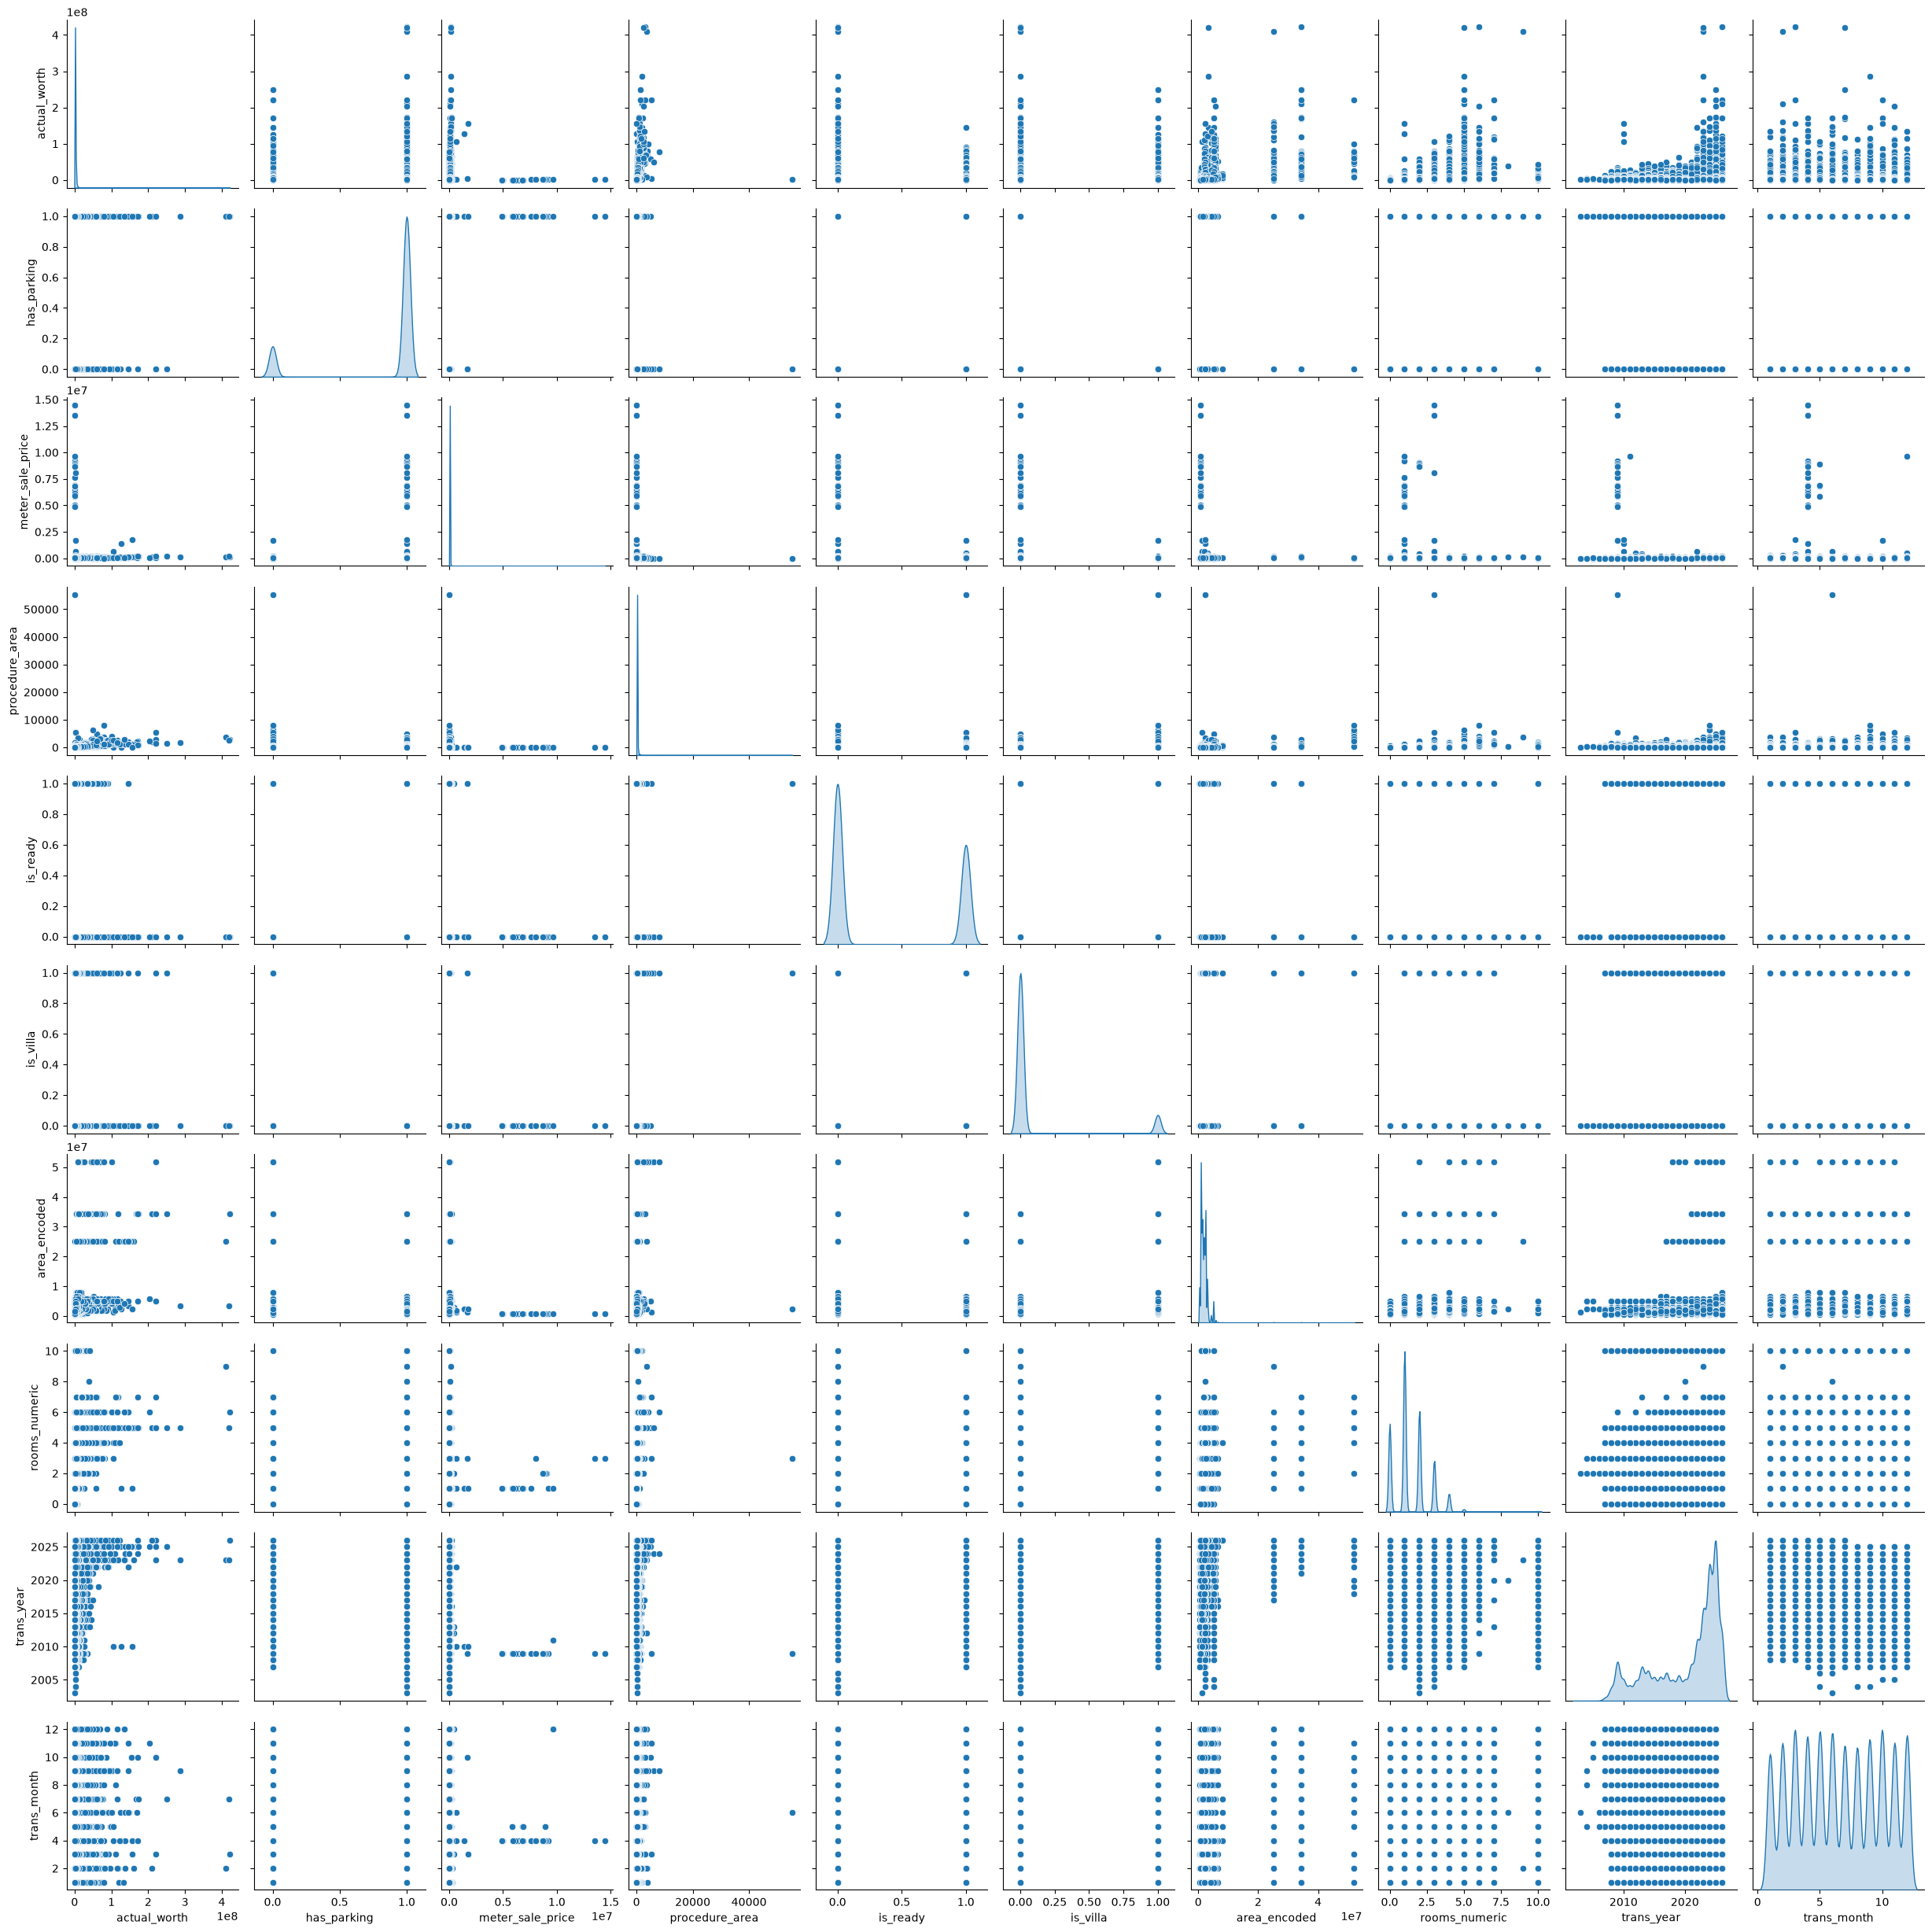

In [139]:
#Data Distribution across columns
sns.pairplot(capstone_onlyEnglish_cleaned, diag_kind='kde')

<Axes: ylabel='actual_worth'>

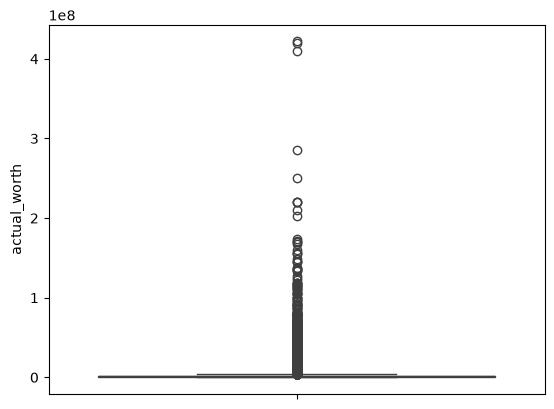

In [140]:
#To check the presence of outliers in 'actual_worth'
sns.boxplot(capstone_onlyEnglish_cleaned['actual_worth'])

<Axes: ylabel='meter_sale_price'>

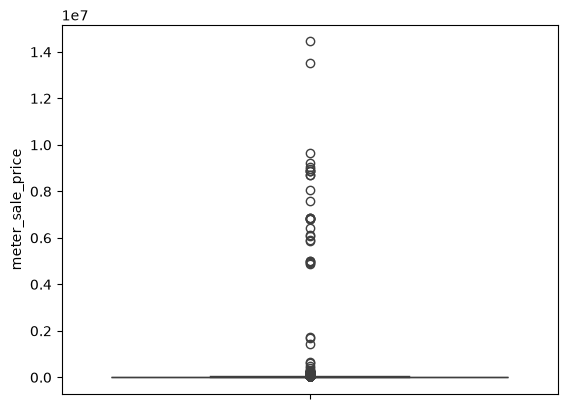

In [141]:
#To check the presence of outliers in 'meter_sale_price'
sns.boxplot(capstone_onlyEnglish_cleaned['meter_sale_price'])

<Axes: ylabel='procedure_area'>

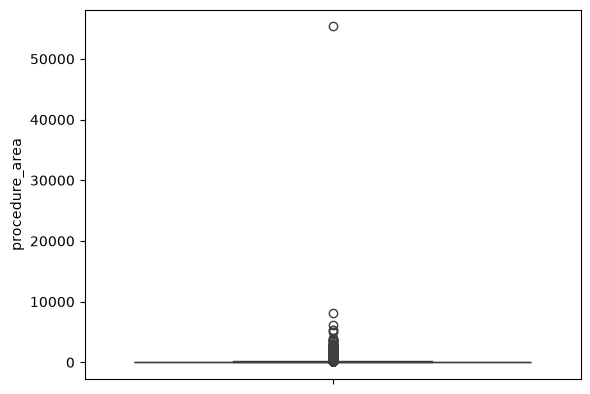

In [142]:
#To check the presence of outliers in 'procedure_area'
sns.boxplot(capstone_onlyEnglish_cleaned['procedure_area'])

In [182]:
capstone_onlyEnglish_cleaned.shape

(458121, 13)

In [183]:
# Define extreme boundaries (e.g., top 0.1% and bottom 0.1%)
upper_limit = capstone_onlyEnglish_cleaned['actual_worth'].quantile(0.999)
lower_limit = capstone_onlyEnglish_cleaned['actual_worth'].quantile(0.001)

# Filter the dataset
capstone_onlyEnglish_cleaned_noOutliers = capstone_onlyEnglish_cleaned[(capstone_onlyEnglish_cleaned['actual_worth'] >= lower_limit) & 
    (capstone_onlyEnglish_cleaned['actual_worth'] <= upper_limit)]

In [184]:
capstone_onlyEnglish_cleaned_noOutliers.shape

(457213, 13)

In [186]:
# Write to a csv file
capstone_onlyEnglish_cleaned_noOutliers.to_csv('RealEstateTransactions_Cleaned.csv', index=False)

In [285]:
capstone_onlyEnglish_cleaned_noOutliers_target = capstone_onlyEnglish_cleaned_noOutliers['actual_worth']

In [286]:
capstone_onlyEnglish_cleaned_noOutliers_target.shape

(457213,)

In [287]:
capstone_onlyEnglish_cleaned_noOutliers_Independent = capstone_onlyEnglish_cleaned_noOutliers

In [288]:
capstone_onlyEnglish_cleaned_noOutliers_Independent.shape

(457213, 13)

In [289]:
capstone_onlyEnglish_cleaned_noOutliers_Independent = capstone_onlyEnglish_cleaned_noOutliers_Independent.drop(labels = "actual_worth", axis = 1)

In [290]:
capstone_onlyEnglish_cleaned_noOutliers_Independent.shape

(457213, 12)

In [295]:
capstone_onlyEnglish_cleaned_noOutliers_Independent.head()

,has_parking,meter_sale_price,nearest_landmark_en,nearest_mall_en,nearest_metro_en,procedure_area,is_ready,is_villa,area_encoded,rooms_numeric,trans_year,trans_month
0,0,11587.49,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,138.08,1,1,9.238604e+05,3,2018,4
2,1,19983.35,Downtown Dubai,Dubai Mall,Buj Khalifa Dubai Mall Metro Station,48.04,1,0,1.906036e+06,0,2024,6
3,0,7044.44,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,45.00,1,0,3.830735e+05,0,2013,8
4,1,19027.94,Burj Al Arab,Marina Mall,Jumeirah Lakes Towers,91.97,0,0,2.393726e+06,1,2022,11
6,1,13020.83,Burj Al Arab,Mall of the Emirates,Dubai Internet City,144.00,1,0,1.496081e+06,2,2025,12


In [304]:
#Applying Multiple Linear Regression
X = capstone_onlyEnglish_cleaned_noOutliers_Independent.drop(columns=['nearest_landmark_en', 
                                                                      'nearest_mall_en', 'nearest_metro_en'], errors='ignore')
X = np.array(capstone_onlyEnglish_cleaned_noOutliers_Independent)
y = np.array(capstone_onlyEnglish_cleaned_noOutliers_target)
test_size = 0.30 # taking 70:30 training and test set
seed = 40
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


In [306]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

def run_mlr_model(df, target_col='actual_worth'):
    """
    Executes a Multiple Linear Regression model to answer RQ1.
    Evaluates predictive accuracy and extracts feature coefficients.
    """
    print("--- Starting Multiple Linear Regression (RQ1) ---")
    
    # 1. Define Features (X) and Target (y)
    # Drop the target column and any remaining non-numeric/unencoded text columns
    # Adjust the drop list if you have other specific columns to exclude from training
    X = df.drop(columns=[target_col, 'nearest_landmark_en', 
                         'nearest_mall_en', 'nearest_metro_en'], errors='ignore')
    
    # Ensure all remaining X columns are strictly numeric
    X = X.select_dtypes(include=[np.number])
    y = df[target_col]
    
    # 2. Train-Test Split (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. Feature Scaling (Optional but highly recommended for MLR)
    # Standardizing helps compare the relative impact of coefficients (e.g., area vs. rooms)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Initialize and Train the Model
    mlr_model = LinearRegression()
    mlr_model.fit(X_train_scaled, y_train)
    
    # 5. Generate Predictions
    y_pred = mlr_model.predict(X_test_scaled)
    
    # 6. Evaluate Model Performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("\n--- Model Evaluation Metrics ---")
    print(f"R-squared (R2): {r2:.4f} (Explains {r2*100:.2f}% of the variance in price)")
    print(f"Mean Absolute Error (MAE): AED {mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): AED {rmse:,.2f}")
    
    # 7. Extract and Display Coefficients for the Report
    # We map the coefficients back to the original column names
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient (Scaled Impact)': mlr_model.coef_
    }).sort_values(by='Coefficient (Scaled Impact)', ascending=False)
    
    print("\n--- Feature Coefficients (How much each variable impacts price) ---")
    print(coefficients.to_string(index=False))
    
    return mlr_model, scaler, coefficients

In [307]:
model, scaler, coefs = run_mlr_model(capstone_onlyEnglish_cleaned_noOutliers)

--- Starting Multiple Linear Regression (RQ1) ---

--- Model Evaluation Metrics ---
R-squared (R2): 0.5029 (Explains 50.29% of the variance in price)
Mean Absolute Error (MAE): AED 656,444.28
Root Mean Squared Error (RMSE): AED 1,401,843.53

--- Feature Coefficients (How much each variable impacts price) ---
         Feature  Coefficient (Scaled Impact)
   rooms_numeric                854355.472957
    area_encoded                651820.550325
  procedure_area                404771.578337
      trans_year                322519.542569
meter_sale_price                 90983.828259
     trans_month                  7284.266894
        is_ready               -138751.802495
     has_parking               -197043.695122
        is_villa               -486746.150412


# Data set 2: Ejari/Rental Contracts

In [187]:
#Read the data as a dataframe
capstone_ejari = pd.read_csv('rent_contracts_2026-07-08_18-34-43_0001.csv')

In [188]:
capstone_ejari.shape

(1024931, 41)

In [189]:
capstone_ejari.head()

,actual_area,annual_amount,area_id,area_name_ar,area_name_en,contract_amount,contract_end_date,contract_id,contract_reg_type_ar,contract_reg_type_en,...,no_of_prop,project_name_ar,project_name_en,project_number,property_usage_ar,property_usage_en,tenant_type_ar,tenant_type_en,tenant_type_id,load_timestamp
0,5431.0,86625.0,232.0,مردف,Mirdif,86625.0,2025-01-04,CNT2114475016,جديد,New,...,1,NaN,NaN,NaN,سكني,Residential,شخص,Person,0.0,2026-07-08T18:25:35.000Z
1,55.0,32500.0,339.0,المرر,Al Mararr,32500.0,2022-12-31,CNT1823006931,تجديد,Renew,...,1,NaN,NaN,NaN,تجاري,Commercial,جهة,Authority,1.0,2026-07-08T18:25:35.000Z
2,1.0,180000.0,359.0,الطوار الثالثه,Al Twar Third,180000.0,2022-01-31,CRT1480009276,تجديد,Renew,...,1,NaN,NaN,NaN,سكني,Residential,شخص,Person,0.0,2026-07-08T18:25:35.000Z
3,106.1,180000.0,526.0,الخليج التجارى,Business Bay,60000.0,2025-03-21,CNT2125814966,تجديد,Renew,...,1,NaN,NaN,NaN,تجاري,Commercial,جهة,Authority,1.0,2026-07-08T18:25:35.000Z
4,96.0,57000.0,267.0,الرفاعه,Al Raffa,57000.0,2022-02-28,CNT1377977270,تجديد,Renew,...,1,NaN,NaN,NaN,سكني,Residential,جهة,Authority,1.0,2026-07-08T18:25:35.000Z


In [190]:
capstone_ejari.dtypes

actual_area                   float64
annual_amount                 float64
area_id                       float64
area_name_ar                      str
area_name_en                      str
contract_amount               float64
contract_end_date                 str
contract_id                       str
contract_reg_type_ar              str
contract_reg_type_en              str
contract_reg_type_id            int64
contract_start_date               str
ejari_bus_property_type_ar        str
ejari_bus_property_type_en        str
ejari_bus_property_type_id    float64
ejari_property_sub_type_ar        str
ejari_property_sub_type_en        str
ejari_property_sub_type_id    float64
ejari_property_type_ar            str
ejari_property_type_en            str
ejari_property_type_id        float64
is_free_hold                  float64
line_number                     int64
master_project_ar                 str
master_project_en                 str
nearest_landmark_ar               str
nearest_land

In [191]:
capstone_ejari['contract_end_date'] = pd.to_datetime(capstone_ejari['contract_end_date'], errors='coerce')

In [192]:
capstone_ejari['contract_start_date'] = pd.to_datetime(capstone_ejari['contract_start_date'], errors='coerce')

In [193]:
cols_to_drop_ejari = capstone_ejari.columns[capstone_ejari.columns.str.endswith('_ar')]
capstone_ejari_onlyEnglish = capstone_ejari.drop(columns=cols_to_drop_ejari)

In [194]:
capstone_ejari_onlyEnglish.shape

(1024931, 29)

In [195]:
capstone_ejari_onlyEnglish.head()

,actual_area,annual_amount,area_id,area_name_en,contract_amount,contract_end_date,contract_id,contract_reg_type_en,contract_reg_type_id,contract_start_date,...,nearest_landmark_en,nearest_mall_en,nearest_metro_en,no_of_prop,project_name_en,project_number,property_usage_en,tenant_type_en,tenant_type_id,load_timestamp
0,5431.0,86625.0,232.0,Mirdif,86625.0,2025-01-04,CNT2114475016,New,1,2024-01-05,...,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,1,NaN,NaN,Residential,Person,0.0,2026-07-08T18:25:35.000Z
1,55.0,32500.0,339.0,Al Mararr,32500.0,2022-12-31,CNT1823006931,Renew,2,2022-01-01,...,Dubai International Airport,Dubai Mall,Baniyas Square Metro Station,1,NaN,NaN,Commercial,Authority,1.0,2026-07-08T18:25:35.000Z
2,1.0,180000.0,359.0,Al Twar Third,180000.0,2022-01-31,CRT1480009276,Renew,2,2020-11-15,...,Dubai International Airport,City Centre Mirdif,Al Qusais Metro Station,1,NaN,NaN,Residential,Person,0.0,2026-07-08T18:25:35.000Z
3,106.1,180000.0,526.0,Business Bay,60000.0,2025-03-21,CNT2125814966,Renew,2,2024-11-22,...,Burj Khalifa,Dubai Mall,Business Bay Metro Station,1,NaN,NaN,Commercial,Authority,1.0,2026-07-08T18:25:35.000Z
4,96.0,57000.0,267.0,Al Raffa,57000.0,2022-02-28,CNT1377977270,Renew,2,2020-12-01,...,Burj Khalifa,Dubai Mall,Al Ghubaiba Metro Station,1,NaN,NaN,Residential,Authority,1.0,2026-07-08T18:25:35.000Z


In [196]:
#Checking the presence of null values
capstone_ejari_onlyEnglish.isnull().sum()

actual_area                   127707
annual_amount                      0
area_id                            1
area_name_en                       1
contract_amount                    0
contract_end_date                  0
contract_id                        0
contract_reg_type_en               0
contract_reg_type_id               0
contract_start_date                0
ejari_bus_property_type_en       337
ejari_bus_property_type_id       337
ejari_property_sub_type_en      7483
ejari_property_sub_type_id      6863
ejari_property_type_en          6730
ejari_property_type_id          6621
is_free_hold                     337
line_number                        0
master_project_en             688128
nearest_landmark_en            70652
nearest_mall_en               121544
nearest_metro_en              112249
no_of_prop                         0
project_name_en               868583
project_number                868583
property_usage_en               1436
tenant_type_en                 40379
t

In [197]:
capstone_ejari_onlyEnglish = capstone_ejari_onlyEnglish.drop(columns=['contract_id', 'area_id', 'contract_reg_type_id', 
                                                                      'ejari_bus_property_type_id', 'ejari_property_sub_type_id',
                                                                     'ejari_property_type_id', 'line_number', 'tenant_type_id',
                                                                     'project_name_en', 'master_project_en'])

In [198]:
capstone_ejari_onlyEnglish.shape

(1024931, 19)

In [199]:
capstone_ejari_onlyEnglish.head()

,actual_area,annual_amount,area_name_en,contract_amount,contract_end_date,contract_reg_type_en,contract_start_date,ejari_bus_property_type_en,ejari_property_sub_type_en,ejari_property_type_en,is_free_hold,nearest_landmark_en,nearest_mall_en,nearest_metro_en,no_of_prop,project_number,property_usage_en,tenant_type_en,load_timestamp
0,5431.0,86625.0,Mirdif,86625.0,2025-01-04,New,2024-01-05,Villa,3 bed rooms+hall,Villa,0.0,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,1,NaN,Residential,Person,2026-07-08T18:25:35.000Z
1,55.0,32500.0,Al Mararr,32500.0,2022-12-31,Renew,2022-01-01,Unit,Office,Office,0.0,Dubai International Airport,Dubai Mall,Baniyas Square Metro Station,1,NaN,Commercial,Authority,2026-07-08T18:25:35.000Z
2,1.0,180000.0,Al Twar Third,180000.0,2022-01-31,Renew,2020-11-15,Villa,5 bed rooms+hall,Villa,0.0,Dubai International Airport,City Centre Mirdif,Al Qusais Metro Station,1,NaN,Residential,Person,2026-07-08T18:25:35.000Z
3,106.1,180000.0,Business Bay,60000.0,2025-03-21,Renew,2024-11-22,Unit,Office,Office,1.0,Burj Khalifa,Dubai Mall,Business Bay Metro Station,1,NaN,Commercial,Authority,2026-07-08T18:25:35.000Z
4,96.0,57000.0,Al Raffa,57000.0,2022-02-28,Renew,2020-12-01,Unit,1bed room+Hall,Flat,0.0,Burj Khalifa,Dubai Mall,Al Ghubaiba Metro Station,1,NaN,Residential,Authority,2026-07-08T18:25:35.000Z


In [200]:
print(capstone_ejari_onlyEnglish['project_number'].value_counts())
print("***********")

project_number
975.0     2853
794.0     2270
436.0     1799
1288.0    1478
1042.0    1295
          ... 
2772.0       1
2839.0       1
2071.0       1
3338.0       1
2160.0       1
Name: count, Length: 1548, dtype: int64
***********


In [201]:
capstone_ejari_onlyEnglish = capstone_ejari_onlyEnglish.drop(columns=['project_number'])

In [202]:
capstone_ejari_onlyEnglish.shape

(1024931, 18)

In [203]:
capstone_ejari_onlyEnglish.head()

,actual_area,annual_amount,area_name_en,contract_amount,contract_end_date,contract_reg_type_en,contract_start_date,ejari_bus_property_type_en,ejari_property_sub_type_en,ejari_property_type_en,is_free_hold,nearest_landmark_en,nearest_mall_en,nearest_metro_en,no_of_prop,property_usage_en,tenant_type_en,load_timestamp
0,5431.0,86625.0,Mirdif,86625.0,2025-01-04,New,2024-01-05,Villa,3 bed rooms+hall,Villa,0.0,Dubai International Airport,City Centre Mirdif,Rashidiya Metro Station,1,Residential,Person,2026-07-08T18:25:35.000Z
1,55.0,32500.0,Al Mararr,32500.0,2022-12-31,Renew,2022-01-01,Unit,Office,Office,0.0,Dubai International Airport,Dubai Mall,Baniyas Square Metro Station,1,Commercial,Authority,2026-07-08T18:25:35.000Z
2,1.0,180000.0,Al Twar Third,180000.0,2022-01-31,Renew,2020-11-15,Villa,5 bed rooms+hall,Villa,0.0,Dubai International Airport,City Centre Mirdif,Al Qusais Metro Station,1,Residential,Person,2026-07-08T18:25:35.000Z
3,106.1,180000.0,Business Bay,60000.0,2025-03-21,Renew,2024-11-22,Unit,Office,Office,1.0,Burj Khalifa,Dubai Mall,Business Bay Metro Station,1,Commercial,Authority,2026-07-08T18:25:35.000Z
4,96.0,57000.0,Al Raffa,57000.0,2022-02-28,Renew,2020-12-01,Unit,1bed room+Hall,Flat,0.0,Burj Khalifa,Dubai Mall,Al Ghubaiba Metro Station,1,Residential,Authority,2026-07-08T18:25:35.000Z


In [205]:
print(capstone_ejari_onlyEnglish['ejari_property_type_en'].value_counts())
print("***********")

ejari_property_type_en
Flat              533160
Office            153892
Labor Camps       117897
Shop               90667
Villa              60442
                   ...  
Sports Club            3
Petrol station         3
Laundry                2
Hall                   2
church                 1
Name: count, Length: 64, dtype: int64
***********


In [207]:
capstone_ejari_onlyEnglish['ejari_property_type_en'].unique()


<StringArray>
[                         'Villa',                         'Office',
                           'Flat',                         'Studio',
                    'Labor Camps',                           'Shop',
                      'Warehouse',                 'Complex Villas',
                     'Portacabin',               'Hotel apartments',
                          'Hotel',                     'Restaurant',
                       'Showroom',                       'Hospital',
            'Staff Accommodation',                              nan,
                          'Store',                       'Workshop',
              'Warehouse complex',                        'Factory',
                          'Kiosk',                  'Ladies Saloon',
                         'Clinic',                  'Arabian House',
                         'Garage',                        'Parking',
   'Supermarket, a multi-section',                      'Mezzanine',
              'Compl

In [208]:
capstone_ejari_onlyEnglish['ejari_bus_property_type_en'].unique()

<StringArray>
['Villa', 'Unit', 'Virtual Unit', 'Land', 'Building', nan]
Length: 6, dtype: str

In [209]:
capstone_ejari_onlyEnglish['ejari_property_sub_type_en'].unique()

<StringArray>
[           '3 bed rooms+hall',                      'Office',
            '5 bed rooms+hall',              '1bed room+Hall',
                      'Studio',          'Room in labor Camp',
                        'Shop',                   'Warehouse',
            '2 bed rooms+hall',                  'Labor Camp',
            '4 bed rooms+hall',           '10 bed rooms+hall',
            'Portacabin Rooms',                    'Showroom',
                       'Hotel',                  'Restaurant',
       'Shop with a mezzanine',                    'Hospital',
        'Staff Accommodatoion',                           nan,
            'Hotel apartments',                     'Storage',
                    'Workshop',            '6 bed rooms+hall',
     'Showroom with mezzanine',                       'Store',
                      'Clinic',                       'Kiosk',
               'Ladies Saloon',                        'Room',
                      'Duplex',          

In [211]:
# property_usage_en
capstone_ejari_onlyEnglish['property_usage_en'].unique()

<StringArray>
[                          'Residential',
                            'Commercial',
                            'Industrial',
               'Industrial / Commercial',
                           'Multi Usage',
                                     nan,
                               'Storage',
 'Industrial / Commercial / Residential',
                  'Educational facility',
                           'Agriculture',
                        'Tourist origin',
                       'Health Facility',
              'Residential / Commercial']
Length: 13, dtype: str

In [221]:
capstone_ejari_onlyEnglish['is_free_hold'].unique()

array([ 0.,  1., nan])

In [222]:
print(capstone_ejari_onlyEnglish['is_free_hold'].value_counts())
print("***********")

is_free_hold
0.0    636544
1.0    388050
Name: count, dtype: int64
***********


In [237]:
print(capstone_ejari_onlyEnglish['no_of_prop'].value_counts())
print("***********")

no_of_prop
1      832572
2       22136
3       10641
4        8206
5        6803
        ...  
233        21
314        20
227        19
245        19
246        17
Name: count, Length: 355, dtype: int64
***********


In [238]:
capstone_ejari_onlyEnglish['no_of_prop'] == 1

0           True
1           True
2           True
3           True
4           True
           ...  
1024926     True
1024927    False
1024928     True
1024929     True
1024930     True
Name: no_of_prop, Length: 1024931, dtype: bool

In [252]:
condition_1 = capstone_ejari_onlyEnglish['property_usage_en'] == 'Residential'
condition_2 = capstone_ejari_onlyEnglish['ejari_property_type_en'].isin(['Villa', 'Flat', 'Studio', 'Penthouse'])
condition_3 = capstone_ejari_onlyEnglish['is_free_hold'] == 1.0
condition_4 = capstone_ejari_onlyEnglish['no_of_prop'] == 1
condition_5 = capstone_ejari_onlyEnglish['contract_reg_type_en'] == 'New' 
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish[condition_1 & condition_2 & condition_3 & condition_4 & condition_5].copy()

In [253]:
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish_cleaned.drop(columns=['contract_amount', 'ejari_bus_property_type_en', 
                                                                                      'load_timestamp', 'tenant_type_en' ])

In [254]:
capstone_ejari_onlyEnglish_cleaned.shape

(153506, 14)

In [255]:
capstone_ejari_onlyEnglish_cleaned.head()

,actual_area,annual_amount,area_name_en,contract_end_date,contract_reg_type_en,contract_start_date,ejari_property_sub_type_en,ejari_property_type_en,is_free_hold,nearest_landmark_en,nearest_mall_en,nearest_metro_en,no_of_prop,property_usage_en
12,34.90,37500.0,Saih Shuaib 2,2027-04-19,New,2026-04-20,Studio,Studio,1.0,Al Makhtoum International Airport,NaN,NaN,1,Residential
22,633.21,150000.0,Al Barsha South Fourth,2016-01-31,New,2015-02-01,2 bed rooms+hall,Villa,1.0,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City,1,Residential
23,109.07,145000.0,Al Thanyah Third,2017-01-16,New,2016-01-17,2 bed rooms+hall,Flat,1.0,Burj Al Arab,Marina Mall,Dubai Internet City,1,Residential
25,74.60,10000.0,Business Bay,2026-02-05,New,2025-02-06,1bed room+Hall,Flat,1.0,Downtown Dubai,Dubai Mall,Business Bay Metro Station,1,Residential
26,82.56,48000.0,Al Warsan First,2021-01-13,New,2020-01-12,2 bed rooms+hall,Flat,1.0,NaN,City Centre Mirdif,Rashidiya Metro Station,1,Residential


In [256]:
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish_cleaned.drop(columns=['property_usage_en', 'no_of_prop', 
                                                                                      'is_free_hold'])

In [257]:
capstone_ejari_onlyEnglish_cleaned.head()

,actual_area,annual_amount,area_name_en,contract_end_date,contract_reg_type_en,contract_start_date,ejari_property_sub_type_en,ejari_property_type_en,nearest_landmark_en,nearest_mall_en,nearest_metro_en
12,34.90,37500.0,Saih Shuaib 2,2027-04-19,New,2026-04-20,Studio,Studio,Al Makhtoum International Airport,NaN,NaN
22,633.21,150000.0,Al Barsha South Fourth,2016-01-31,New,2015-02-01,2 bed rooms+hall,Villa,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City
23,109.07,145000.0,Al Thanyah Third,2017-01-16,New,2016-01-17,2 bed rooms+hall,Flat,Burj Al Arab,Marina Mall,Dubai Internet City
25,74.60,10000.0,Business Bay,2026-02-05,New,2025-02-06,1bed room+Hall,Flat,Downtown Dubai,Dubai Mall,Business Bay Metro Station
26,82.56,48000.0,Al Warsan First,2021-01-13,New,2020-01-12,2 bed rooms+hall,Flat,NaN,City Centre Mirdif,Rashidiya Metro Station


In [258]:
capstone_ejari_onlyEnglish_cleaned.shape

(153506, 11)

In [259]:
# Convert specific columns to the Pandas 'category' dtype
cat_cols_ejari = ['nearest_landmark_en', 'nearest_mall_en', 'nearest_metro_en']
capstone_ejari_onlyEnglish_cleaned[cat_cols_ejari] = capstone_ejari_onlyEnglish_cleaned[cat_cols_ejari].astype('category')

In [260]:
capstone_ejari_onlyEnglish_cleaned.dtypes

actual_area                          float64
annual_amount                        float64
area_name_en                             str
contract_end_date             datetime64[us]
contract_reg_type_en                     str
contract_start_date           datetime64[us]
ejari_property_sub_type_en               str
ejari_property_type_en                   str
nearest_landmark_en                 category
nearest_mall_en                     category
nearest_metro_en                    category
dtype: object

In [261]:
print(capstone_ejari_onlyEnglish_cleaned['ejari_property_sub_type_en'].value_counts())
print("***********")

ejari_property_sub_type_en
1bed room+Hall                 59252
2 bed rooms+hall               36349
Studio                         33823
3 bed rooms+hall               16398
4 bed rooms+hall                5173
5 bed rooms+hall                1964
6 bed rooms+hall                 382
Penthouse                         59
7 bed rooms+hall                  48
Duplex                            17
8 bed rooms+hall                   9
Pharmacy                           2
Shop                               2
2 bed rooms+hall+Maids Room        1
Room                               1
10 bed rooms+hall                  1
Name: count, dtype: int64
***********


In [265]:
# Define the list of non-standard residential values to drop
values_to_drop = ['Duplex', 'Pharmacy', 'Shop', 'Room', '2 bed rooms+hall+Maids Room', '10 bed rooms+hall']

# Apply the filter to remove these values from both relevant columns
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish_cleaned[
    (~capstone_ejari_onlyEnglish_cleaned['ejari_property_sub_type_en'].isin(values_to_drop))
]

# Optional: Verify the filtering worked by printing the remaining unique values

print("\nRemaining Room Categories:")
print(capstone_ejari_onlyEnglish_cleaned['ejari_property_sub_type_en'].unique())


Remaining Room Categories:
<StringArray>
[          'Studio', '2 bed rooms+hall',   '1bed room+Hall',
 '4 bed rooms+hall', '3 bed rooms+hall', '5 bed rooms+hall',
 '6 bed rooms+hall',        'Penthouse', '7 bed rooms+hall',
                nan, '8 bed rooms+hall']
Length: 11, dtype: str


In [266]:
capstone_ejari_onlyEnglish_cleaned.shape

(153482, 11)

In [267]:
print(capstone_ejari_onlyEnglish_cleaned['ejari_property_sub_type_en'].value_counts())
print("***********")

ejari_property_sub_type_en
1bed room+Hall      59252
2 bed rooms+hall    36349
Studio              33823
3 bed rooms+hall    16398
4 bed rooms+hall     5173
5 bed rooms+hall     1964
6 bed rooms+hall      382
Penthouse              59
7 bed rooms+hall       48
8 bed rooms+hall        9
Name: count, dtype: int64
***********


In [271]:
capstone_ejari_onlyEnglish_cleaned.head()

,actual_area,annual_amount,area_name_en,contract_end_date,contract_reg_type_en,contract_start_date,ejari_property_sub_type_en,ejari_property_type_en,nearest_landmark_en,nearest_mall_en,nearest_metro_en
12,34.90,37500.0,Saih Shuaib 2,2027-04-19,New,2026-04-20,Studio,Studio,Al Makhtoum International Airport,NaN,NaN
22,633.21,150000.0,Al Barsha South Fourth,2016-01-31,New,2015-02-01,2 bed rooms+hall,Villa,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City
23,109.07,145000.0,Al Thanyah Third,2017-01-16,New,2016-01-17,2 bed rooms+hall,Flat,Burj Al Arab,Marina Mall,Dubai Internet City
25,74.60,10000.0,Business Bay,2026-02-05,New,2025-02-06,1bed room+Hall,Flat,Downtown Dubai,Dubai Mall,Business Bay Metro Station
26,82.56,48000.0,Al Warsan First,2021-01-13,New,2020-01-12,2 bed rooms+hall,Flat,NaN,City Centre Mirdif,Rashidiya Metro Station


In [272]:
#Checking the presence of null values
capstone_ejari_onlyEnglish_cleaned.isnull().sum()

actual_area                      12
annual_amount                     0
area_name_en                      0
contract_end_date                 0
contract_reg_type_en              0
contract_start_date               0
ejari_property_sub_type_en       25
ejari_property_type_en            0
nearest_landmark_en           22023
nearest_mall_en               34233
nearest_metro_en              34422
dtype: int64

In [274]:
capstone_ejari_onlyEnglish_cleaned.dtypes

actual_area                          float64
annual_amount                        float64
area_name_en                             str
contract_end_date             datetime64[us]
contract_reg_type_en                     str
contract_start_date           datetime64[us]
ejari_property_sub_type_en               str
ejari_property_type_en                   str
nearest_landmark_en                 category
nearest_mall_en                     category
nearest_metro_en                    category
dtype: object

In [275]:
capstone_ejari_onlyEnglish_cleaned['nearest_landmark_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_landmark_en'].cat.add_categories("None")
capstone_ejari_onlyEnglish_cleaned['nearest_landmark_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_landmark_en'].fillna("None")

In [277]:
capstone_ejari_onlyEnglish_cleaned['nearest_mall_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_mall_en'].cat.add_categories("None")
capstone_ejari_onlyEnglish_cleaned['nearest_mall_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_mall_en'].fillna("None")

In [278]:
capstone_ejari_onlyEnglish_cleaned['nearest_metro_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_metro_en'].cat.add_categories("None")
capstone_ejari_onlyEnglish_cleaned['nearest_metro_en'] = capstone_ejari_onlyEnglish_cleaned['nearest_metro_en'].fillna("None")

In [280]:
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish_cleaned.dropna(subset=['actual_area', 'ejari_property_sub_type_en'])

In [281]:
#Checking the presence of null values
capstone_ejari_onlyEnglish_cleaned.isnull().sum()

actual_area                   0
annual_amount                 0
area_name_en                  0
contract_end_date             0
contract_reg_type_en          0
contract_start_date           0
ejari_property_sub_type_en    0
ejari_property_type_en        0
nearest_landmark_en           0
nearest_mall_en               0
nearest_metro_en              0
dtype: int64

In [282]:
capstone_ejari_onlyEnglish_cleaned.head()

,actual_area,annual_amount,area_name_en,contract_end_date,contract_reg_type_en,contract_start_date,ejari_property_sub_type_en,ejari_property_type_en,nearest_landmark_en,nearest_mall_en,nearest_metro_en
12,34.90,37500.0,Saih Shuaib 2,2027-04-19,New,2026-04-20,Studio,Studio,Al Makhtoum International Airport,None,None
22,633.21,150000.0,Al Barsha South Fourth,2016-01-31,New,2015-02-01,2 bed rooms+hall,Villa,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City
23,109.07,145000.0,Al Thanyah Third,2017-01-16,New,2016-01-17,2 bed rooms+hall,Flat,Burj Al Arab,Marina Mall,Dubai Internet City
25,74.60,10000.0,Business Bay,2026-02-05,New,2025-02-06,1bed room+Hall,Flat,Downtown Dubai,Dubai Mall,Business Bay Metro Station
26,82.56,48000.0,Al Warsan First,2021-01-13,New,2020-01-12,2 bed rooms+hall,Flat,None,City Centre Mirdif,Rashidiya Metro Station


In [284]:
capstone_ejari_onlyEnglish_cleaned.shape

(153445, 11)

In [310]:
capstone_ejari_onlyEnglish_cleaned = capstone_ejari_onlyEnglish_cleaned.drop(columns=['contract_reg_type_en'])

In [312]:
capstone_ejari_onlyEnglish_cleaned.shape

(153445, 10)

In [313]:
capstone_ejari_onlyEnglish_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
actual_area,153445.0,718.619614,4.47,60.13,84.06,129.73,911979.07,20191.928188
annual_amount,153445.0,91601.347617,0.2,41000.0,63000.0,105000.0,393080722.0,1014896.337449
contract_end_date,153445,2021-11-18 07:55:37.422529,2011-01-31 00:00:00,2019-02-28 00:00:00,2022-06-30 00:00:00,2025-01-31 00:00:00,2036-01-01 00:00:00,NaN
contract_start_date,153445,2020-11-11 20:37:00.271758,2004-06-01 00:00:00,2018-02-27 00:00:00,2021-06-16 00:00:00,2024-01-26 00:00:00,2026-12-01 00:00:00,NaN


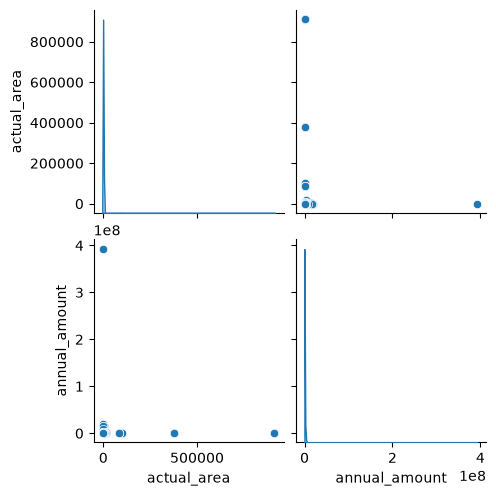

In [314]:
#Data Distribution across columns
sns.pairplot(capstone_ejari_onlyEnglish_cleaned, diag_kind='kde')

<Axes: ylabel='annual_amount'>

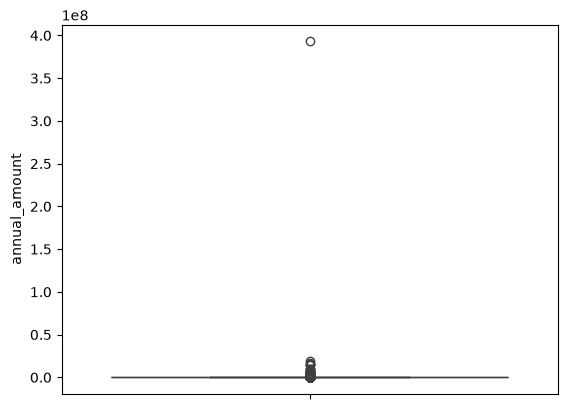

In [315]:
#To check the presence of outliers in 'annual_amount'
sns.boxplot(capstone_ejari_onlyEnglish_cleaned['annual_amount'])

<Axes: ylabel='actual_area'>

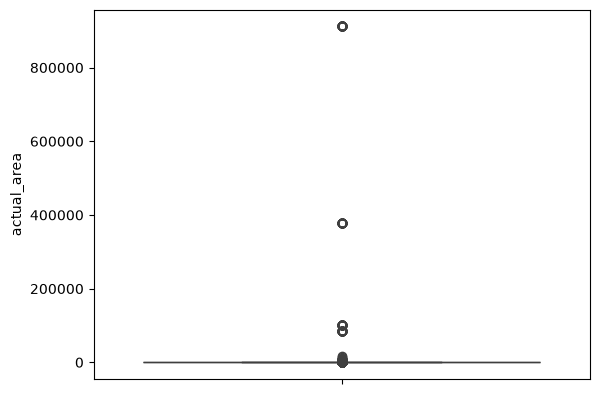

In [316]:
#To check the presence of outliers in 'actual_area'
sns.boxplot(capstone_ejari_onlyEnglish_cleaned['actual_area'])

In [318]:
# Define extreme boundaries (e.g., top 0.1% and bottom 0.1%)
upper_limit = capstone_ejari_onlyEnglish_cleaned['annual_amount'].quantile(0.999)
lower_limit = capstone_ejari_onlyEnglish_cleaned['annual_amount'].quantile(0.001)

# Filter the dataset
capstone_ejari_onlyEnglish_cleaned_noOutliers = capstone_ejari_onlyEnglish_cleaned[(capstone_ejari_onlyEnglish_cleaned['annual_amount'] >= lower_limit) & 
    (capstone_ejari_onlyEnglish_cleaned['annual_amount'] <= upper_limit)]

In [319]:
capstone_ejari_onlyEnglish_cleaned_noOutliers.shape

(153137, 10)

In [320]:
capstone_ejari_onlyEnglish_cleaned_noOutliers.head()

,actual_area,annual_amount,area_name_en,contract_end_date,contract_start_date,ejari_property_sub_type_en,ejari_property_type_en,nearest_landmark_en,nearest_mall_en,nearest_metro_en
12,34.90,37500.0,Saih Shuaib 2,2027-04-19,2026-04-20,Studio,Studio,Al Makhtoum International Airport,None,None
22,633.21,150000.0,Al Barsha South Fourth,2016-01-31,2015-02-01,2 bed rooms+hall,Villa,Sports City Swimming Academy,Mall of the Emirates,Dubai Internet City
23,109.07,145000.0,Al Thanyah Third,2017-01-16,2016-01-17,2 bed rooms+hall,Flat,Burj Al Arab,Marina Mall,Dubai Internet City
25,74.60,10000.0,Business Bay,2026-02-05,2025-02-06,1bed room+Hall,Flat,Downtown Dubai,Dubai Mall,Business Bay Metro Station
26,82.56,48000.0,Al Warsan First,2021-01-13,2020-01-12,2 bed rooms+hall,Flat,None,City Centre Mirdif,Rashidiya Metro Station


In [ ]:
# Write to a csv file
capstone_ejari_onlyEnglish_cleaned_noOutliers.to_csv('Ejari_Cleaned.csv', index=False)